
# Operational Profitability Analysis and Demand Forecasting

Information:

- **Sector:** Hospitality and Restaurant Industry
- **Simulated Company:** Restaurant 'El Rincón' | 50 Seats, Málaga Centro
- **Period:** January 2023 – December 2024
- **Dataset:** Created with Random Forest + Real Sector Distributions

Situation:

A family-owned restaurant in Málaga Centro has contacted me to carry out an operational profitability analysis and demand forecasting.

They have some basic knowledge, such as:
-   The days that go well for them.
-   High season.
-   That they have more customers in the evenings.

They decide to contact me to better understand their data and make informed decisions that help the business grow.

-------------------------------------------------

## Imports and Configuration

In [1]:
# LIBRARIES 
import numpy as np                          # Mathematical operations and random number generation
import pandas as pd                         # Data table creation and manipulation (DataFrames)
import matplotlib.pyplot as plt             # Charts and visualizations

# MACHINE LEARNING 
from sklearn.ensemble import RandomForestRegressor    # Random Forest regression model
from sklearn.model_selection import train_test_split  # Split data into training and test sets
from sklearn.metrics import mean_absolute_error, r2_score  # Model evaluation metrics

# STATISTICS 
from scipy import stats                     # Correlations and hypothesis testing

# WARNINGS 
import warnings
warnings.filterwarnings("ignore")           # Suppress unnecessary warnings

# RANDOM SEED 
# Fixing the seed guarantees reproducibility: every run produces the same dataset.
np.random.seed(42)

# COLOR PALETTE 
COLORS = {
    "green":  "#2ECC71",  # Positive values / best results
    "red":    "#E74C3C",  # Alerts / worst results
    "blue":   "#2980B9",  # Main neutral color
    "orange": "#E67E22",  # Secondary color / second group
    "purple": "#8E44AD",  # Third group
    "gray":   "#95A5A6",  # Secondary elements
    "bg":     "#F8F9FA",  # Chart background
    "text":   "#2C3E50",  # Title text color
}

# GLOBAL CHART STYLE 
# rcParams applies these settings to every chart in the notebook automatically,
# so there is no need to repeat styling on each individual plot.
plt.rcParams.update({
    "font.family":        "DejaVu Sans",  # Clean, readable font
    "font.size":          10,             # Base font size
    "axes.facecolor":     COLORS["bg"],   # Light gray chart area background
    "figure.facecolor":   "white",        # White figure container background
    "axes.spines.top":    False,          # Remove top border for a cleaner look
    "axes.spines.right":  False,          # Remove right border for a cleaner look
})

-------------------------------------------------

## Dataset Creation with Random Forest
The dataset simulates 1,200 daily shift records over 2 years.

RandomForestRegressor ensures that net profit is **consistent** with the operational variables, not purely random.

In [2]:
# DATASET SIZE 
# 1,200 records represent approximately 2 years of operation,
# with ~1.5 shifts recorded per day (lunch and/or dinner).
n = 1200

# DATES 
# Generate n random dates within the 2023–2024 range.
# sorted() orders them chronologically so the dataset makes temporal sense.
dates = sorted(pd.to_datetime(
    np.random.choice(pd.date_range("2023-01-01", "2024-12-31"), size=n)
))

# Extract month (1–12) and day name from each date.
# Both are needed separately to apply seasonality factors.
month     = np.array([d.month for d in dates])
day_name  = np.array([d.day_name() for d in dates]) 

# SHIFT 
# Each record is one shift: 55% lunch, 45% dinner.
shift = np.random.choice(["Lunch", "Dinner"], n, p=[0.55, 0.45])

# SEASONALITY FACTORS
# Málaga has a strong tourist seasonality pattern.
# season_factor: scales activity by month.
#   Summer (Jun–Sep):  +40% activity
#   Winter (Dec–Feb):  −22% activity
#   Rest of the year:   normal (1.0)
season_factor = np.where(np.isin(month, [6,7,8,9]), 1.40,
                np.where(np.isin(month, [12,1,2]), 0.78, 1.0))

# day_factor: scales activity by day of the week.
#   Fri/Sat/Sun: +32% (strong days)
#   Monday:      −32% (weakest day)
#   Other days:   normal (1.0)
day_factor = np.where(np.isin(day_name, ["Friday","Saturday","Sunday"]), 1.32,
             np.where(day_name == "Monday", 0.68, 1.0))

# COVERS (GUESTS) 
# Base: normal distribution with mean 40 and std 10.
# Multiplied by seasonality factors to produce realistic values.
# clip() constrains values between 6 and 95 (physical min/max of the restaurant).
covers = np.clip(
    np.random.normal(40, 10, n) * season_factor * day_factor, 6, 95
).astype(int)

# AVERAGE TICKET PER GUEST 
# Dinner has a higher ticket than lunch (real-world behavior).
# Also affected by season: tourists spend more in summer.
ticket = np.clip(
    np.where(shift == "Dinner",
             np.random.normal(27, 5, n),   # Dinner: mean €27, std €5
             np.random.normal(17, 4, n))   # Lunch:  mean €17, std €4
    * season_factor,
    9, 62   # Min €9, max €62
).round(2)

# TOTAL SALES 
sales = (covers * ticket).round(2)

# OPERATING COSTS 
# Food cost %: ingredient cost as a percentage of sales. Healthy range: 28–35%.
food_cost_pct  = np.clip(np.random.normal(31, 4, n), 22, 45).round(1)

# Staff %: staff cost as a percentage of sales. Healthy range: 28–35%.
staff_pct      = np.clip(np.random.normal(30, 5, n), 20, 50).round(1)

# Other fixed costs per shift: rent, utilities, etc. Mean €190/shift.
other_costs    = np.random.normal(190, 45, n).clip(80, 400)

food_cost_eur  = (sales * food_cost_pct / 100).round(2)
staff_cost_eur = (sales * staff_pct / 100).round(2)

# Prime cost = food cost + staff cost. Most important operational KPI.
# If it exceeds 65%, the restaurant has a profitability problem.
prime_cost_pct = (food_cost_pct + staff_pct).round(1)

# Net profit per shift: sales minus all costs.
net_profit     = (sales - food_cost_eur - staff_cost_eur - other_costs).round(2)

# EFFICIENCY METRICS 
# RevPASH: Revenue Per Available Seat Hour — the most precise efficiency KPI.
# Formula: sales / (seats × service hours). Restaurant has 50 seats.
revpash        = (sales / (50 * np.where(shift == "Dinner", 4.5, 3.5))).round(2)

# Table turnover: how many times the restaurant "fills up" per shift.
table_turnover = (covers / 25).round(2)

# ADDITIONAL VARIABLES 
# Waste %: percentage of food cost that is discarded. Mean 8%, range 1–20%.
waste_pct = np.clip(np.random.normal(8, 3, n), 1, 20).round(1)

# OUTDOOR TEMPERATURE 
# cos((month−7)×π/6) peaks in July (month=7) and valleys in January (month=1),
# consistent with Málaga's real climate (hot summers, mild winters).
# Base 24°C + amplitude 9°C → January ≈ 15°C, July ≈ 33°C.
# Previous formula used sin(month×π/6), which inverted the cycle entirely.
temperature = np.clip(
    24 + np.cos((month - 7) * np.pi/6) * 9 + np.random.normal(0, 2, n),
    8, 42   # Range: mild winter lows, summer heat waves up to 42°C
).round(1)

# BOOKING CHANNEL 
# Channel through which the reservation arrived. Based on real sector data.
booking_channel = np.random.choice(
    ["Walk-in", "Phone", "Google Maps", "WhatsApp", "Website"],
    n, p=[0.35, 0.25, 0.20, 0.12, 0.08]
)

# Google rating for that period. Mean 4.1 out of 5.
google_rating = np.clip(np.random.normal(4.1, 0.4, n), 1.0, 5.0).round(1)

# STAFF PER SHIFT 
# np.round() before .astype(int) ensures proper rounding (e.g. 4.8 → 5, not 4).
# The previous .astype(int) truncated instead of rounding, biasing the mean down.
staff_count = np.clip(
    np.round(np.random.normal(5, 1.5, n) * season_factor), 2, 10
).astype(int)

# BUILD DATAFRAME 
# Each row = one shift. Each column = one business variable.
df = pd.DataFrame({
    "date":             dates,
    "month":            month,
    "day_of_week":      day_name,
    "shift":            shift,
    "covers":           covers,
    "avg_ticket_eur":   ticket,
    "sales_eur":        sales,
    "food_cost_pct":    food_cost_pct,
    "food_cost_eur":    food_cost_eur,
    "staff_cost_eur":   staff_cost_eur,
    "staff_pct":        staff_pct,
    "other_costs_eur":  other_costs.round(2),
    "prime_cost_pct":   prime_cost_pct,
    "net_profit_eur":   net_profit,
    "revpash_eur":      revpash,
    "table_turnover":   table_turnover,
    "waste_pct":        waste_pct,
    "temperature_c":    temperature,
    "booking_channel":  booking_channel,
    "google_rating":    google_rating,
    "staff_count":      staff_count,
})

# RANDOM FOREST: INTERNAL COHERENCE 
# Net profit was generated with a simple linear formula.
# A Random Forest learns the non-linear relationships between operational
# variables and profit, producing a more realistic coherent estimate.
features = ["covers","avg_ticket_eur","food_cost_pct","staff_pct",
            "table_turnover","staff_count"]
X = df[features].values
y = df["net_profit_eur"].values

rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X, y)
df["net_profit_rf_eur"] = rf_model.predict(X).round(2)

# AUTOMATIC VALIDATION 
# Verify the temperature formula is correct before proceeding.
# If this assertion fails, the seasonal formula needs to be reviewed.
avg_temp_by_month = df.groupby("month")["temperature_c"].mean()
assert avg_temp_by_month[7] > avg_temp_by_month[1], \
    "ERROR: July should be warmer than January. Check the temperature formula."
print(f"Temperature check passed: "
      f"January {avg_temp_by_month[1]:.1f}°C | July {avg_temp_by_month[7]:.1f}°C")

# SAVE DATASET 
# index=False prevents pandas from adding an extra row-number column.
import os
os.makedirs("outputs", exist_ok=True)          # Create folder if it doesn't exist
df.to_csv("outputs/dataset_elrincon.csv", index=False)

df.head()

Temperature check passed: January 14.8°C | July 33.1°C


,date,month,day_of_week,shift,covers,avg_ticket_eur,sales_eur,food_cost_pct,food_cost_eur,staff_cost_eur,...,prime_cost_pct,net_profit_eur,revpash_eur,table_turnover,waste_pct,temperature_c,booking_channel,google_rating,staff_count,net_profit_rf_eur
0,2023-01-01,1,Sunday,Lunch,59,13.63,804.17,24.2,194.61,261.36,...,56.7,169.44,4.60,2.36,8.1,15.5,Google Maps,3.7,4,126.42
1,2023-01-01,1,Sunday,Dinner,30,25.17,755.10,35.9,271.08,221.24,...,65.2,132.94,3.36,1.20,8.4,17.5,Walk-in,4.7,2,88.31
2,2023-01-01,1,Sunday,Lunch,33,16.93,558.69,31.4,175.43,160.90,...,60.2,40.21,3.19,1.32,13.3,13.0,Google Maps,4.2,5,28.67
3,2023-01-01,1,Sunday,Dinner,41,13.40,549.40,36.6,201.08,179.65,...,69.3,9.14,2.44,1.64,10.6,13.6,Walk-in,4.3,3,13.15
4,2023-01-02,1,Monday,Lunch,28,11.63,325.64,33.9,110.39,101.27,...,65.0,-45.69,1.86,1.12,4.3,17.2,Walk-in,4.3,5,-34.80



## Simple Analysis

### 1. Average Sales by Day of the Week

 Average Sales by Day of the Week

   Best day: Saturday = €1,456
   Worst day: Monday = €656
   Gap: 2.2x more sales



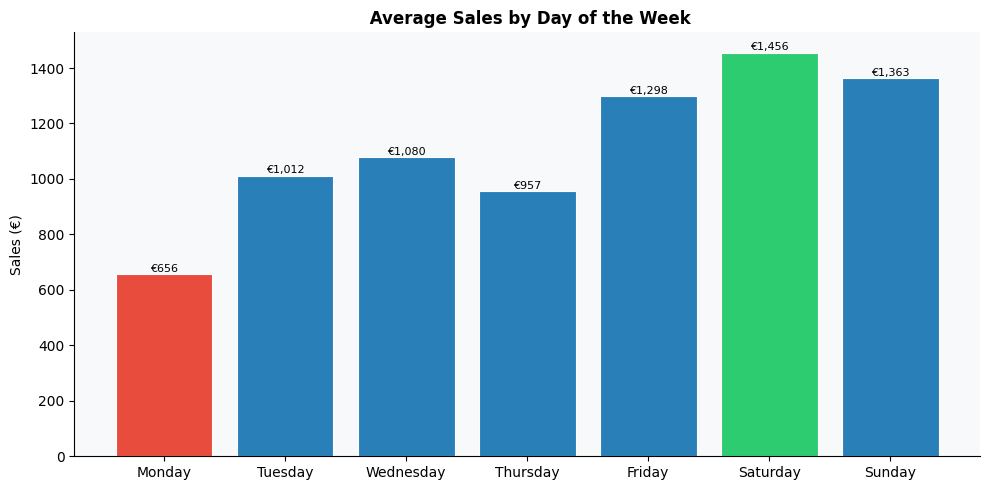


 Recommendations:
   - Maximize Saturday: it is your top-performing day.
   - Consider reducing costs on Monday or evaluating closure.


In [3]:
# DAY ORDER AND LABELS 
DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# CALCULATION 
# groupby aggregates all rows by day of the week.
# mean() calculates average sales per group.
# reindex() ensures days always appear in Monday - Sunday order.
sales_by_day = df.groupby("day_of_week")["sales_eur"].mean().reindex(DAY_ORDER)
best_day     = sales_by_day.idxmax()
worst_day    = sales_by_day.idxmin()

print("=" * 55)
print(" Average Sales by Day of the Week")
print("=" * 55)
print(f"\n   Best day: {best_day} = €{sales_by_day.max():,.0f}")
print(f"   Worst day: {worst_day} = €{sales_by_day.min():,.0f}")
print(f"   Gap: {sales_by_day.max()/sales_by_day.min():.1f}x more sales\n")

# ── CHART ─────────────────────────────────────────────────────────────────────
# Green = best day, red = worst day, blue = all others
bar_colors = [
    COLORS["green"] if v == sales_by_day.max()
    else COLORS["red"] if v == sales_by_day.min()
    else COLORS["blue"]
    for v in sales_by_day.values
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    DAY_ORDER,
    sales_by_day.values,
    color=bar_colors, edgecolor="white", linewidth=0.8
)
ax.set_title(" Average Sales by Day of the Week",
             fontweight="bold", fontsize=12)
ax.set_ylabel("Sales (€)")

# Value labels on top of each bar
for i, v in enumerate(sales_by_day.values):
    ax.text(i, v + 8, f"€{v:,.0f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("outputs/01_sales_by_day.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS 
print(f"\n Recommendations:")
print(f"   - Maximize {best_day}: it is your top-performing day.")
print(f"   - Consider reducing costs on {worst_day} or evaluating closure.")

### 2. Average Ticket by Shift

 Average Ticket by Shift

  Lunch: €17.90 x guest
  Dinner: €28.88 x guest

  Dinner generates €10.98 more per guest (+61%)
  Raising the dinner ticket by €1 = +€1,405/month


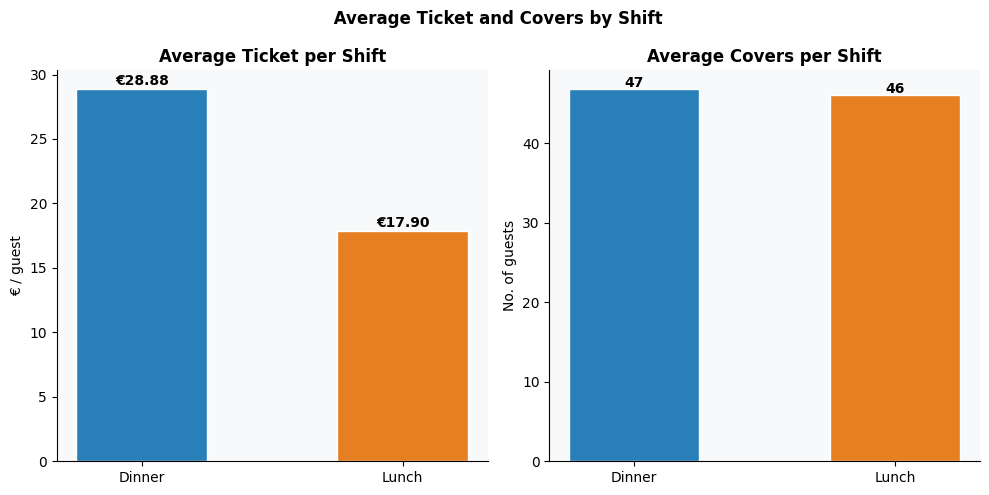


  Recommendations:
  - Dinner has a higher ticket. Design a lunch special
     to raise the midday average without increasing costs.
  - Every extra €1 on the dinner ticket = +€1,405/month.


In [4]:
# CALCULATION 
# Average ticket and covers grouped by shift (Lunch / Dinner)
ticket_by_shift = df.groupby("shift")["avg_ticket_eur"].mean()
covers_by_shift = df.groupby("shift")["covers"].mean()

diff     = ticket_by_shift.get("Dinner", 0) - ticket_by_shift.get("Lunch", 0)
diff_pct = diff / ticket_by_shift.get("Lunch", 1) * 100

# Economic impact: raising the dinner ticket by €1 extra per guest
monthly_impact_1eur = covers_by_shift.get("Dinner", 0) * 30

print("=" * 55)
print(" Average Ticket by Shift")
print("=" * 55)
print(f"\n  Lunch: €{ticket_by_shift.get('Lunch',  0):.2f} x guest")
print(f"  Dinner: €{ticket_by_shift.get('Dinner', 0):.2f} x guest")
print(f"\n  Dinner generates €{diff:.2f} more per guest (+{diff_pct:.0f}%)")
print(f"  Raising the dinner ticket by €1 = +€{monthly_impact_1eur:,.0f}/month")

# CHART
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: average ticket per shift
axes[0].bar(
    ticket_by_shift.index, ticket_by_shift.values,
    color=[COLORS["blue"], COLORS["orange"]],
    edgecolor="white", width=0.5
)
axes[0].set_title("Average Ticket per Shift", fontweight="bold")
axes[0].set_ylabel("€ / guest")
for i, (shift, v) in enumerate(ticket_by_shift.items()):
    axes[0].text(i, v + 0.3, f"€{v:.2f}", ha="center", fontweight="bold")

# Right: average covers per shift
axes[1].bar(
    covers_by_shift.index, covers_by_shift.values,
    color=[COLORS["blue"], COLORS["orange"]],
    edgecolor="white", width=0.5
)
axes[1].set_title("Average Covers per Shift", fontweight="bold")
axes[1].set_ylabel("No. of guests")
for i, (shift, v) in enumerate(covers_by_shift.items()):
    axes[1].text(i, v + 0.3, f"{v:.0f}", ha="center", fontweight="bold")

plt.suptitle(" Average Ticket and Covers by Shift",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/02_ticket_by_shift.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS
print(f"\n  Recommendations:")
print(f"  - Dinner has a higher ticket. Design a lunch special")
print(f"     to raise the midday average without increasing costs.")
print(f"  - Every extra €1 on the dinner ticket = +€{monthly_impact_1eur:,.0f}/month.")

### 3. Food Cost % vs Sector Benchmark

  Food Cost % vs Sector Benchmark

  Your annual food cost: 30.8%
  Sector reference: 28.0% - 35.0%
  Status:  Under control

   All months within the healthy range


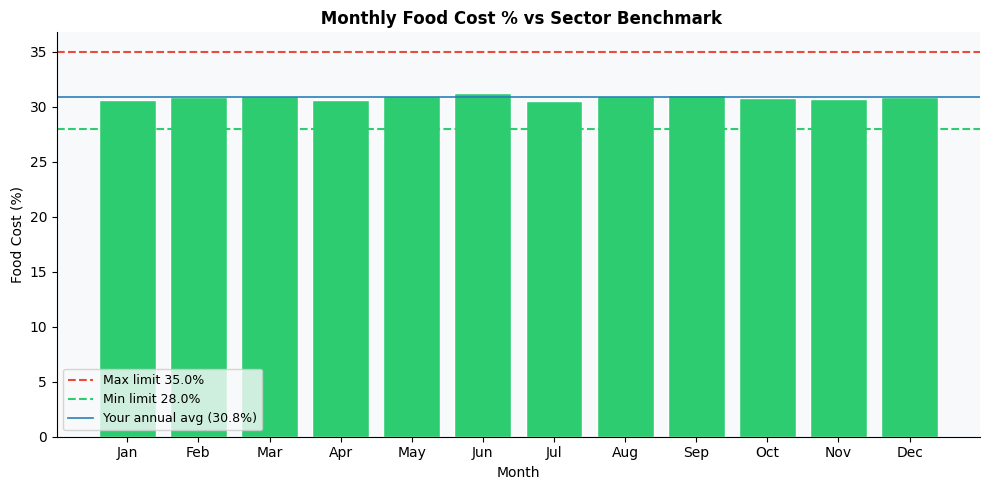


  Recommendations:
  - Monitor food cost every month without exception.
  - One month above 35.0% can wipe out the margin
    accumulated over several good months.


In [5]:
# BENCHMARKS 
# Real benchmarks for the hospitality sector in Spain
BENCHMARK_MIN = 28.0
BENCHMARK_MAX = 35.0

MONTH_LABELS = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

# CALCULATION 
# Average food cost per month and overall annual average
fc_by_month = df.groupby("month")["food_cost_pct"].mean()
fc_annual   = df["food_cost_pct"].mean()

# Months outside the healthy range
months_alert = [MONTH_LABELS[m] for m in fc_by_month[fc_by_month > BENCHMARK_MAX].index]

print("=" * 55)
print("  Food Cost % vs Sector Benchmark")
print("=" * 55)
print(f"\n  Your annual food cost: {fc_annual:.1f}%")
print(f"  Sector reference: {BENCHMARK_MIN}% - {BENCHMARK_MAX}%")
print(f"  Status: {' Under control' if fc_annual <= BENCHMARK_MAX else ' Above the limit'}")

if months_alert:
    print(f"\n    Months above the limit: {months_alert}")
else:
    print(f"\n   All months within the healthy range")

# CHART 
# Red bars = months above the limit, green bars = healthy months
bar_colors = [
    COLORS["red"] if v > BENCHMARK_MAX else COLORS["green"]
    for v in fc_by_month.values
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    [MONTH_LABELS[m] for m in fc_by_month.index],
    fc_by_month.values,
    color=bar_colors, edgecolor="white"
)
ax.axhline(BENCHMARK_MAX, color=COLORS["red"],
           linestyle="--", linewidth=1.5, label=f"Max limit {BENCHMARK_MAX}%")
ax.axhline(BENCHMARK_MIN, color=COLORS["green"],
           linestyle="--", linewidth=1.5, label=f"Min limit {BENCHMARK_MIN}%")
ax.axhline(fc_annual, color=COLORS["blue"],
           linestyle="-", linewidth=1.2,
           label=f"Your annual avg ({fc_annual:.1f}%)")
ax.set_title(" Monthly Food Cost % vs Sector Benchmark",
             fontweight="bold", fontsize=12)
ax.set_ylabel("Food Cost (%)")
ax.set_xlabel("Month")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/03_food_cost.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS
print(f"\n  Recommendations:")
print(f"  - Monitor food cost every month without exception.")
print(f"  - One month above {BENCHMARK_MAX}% can wipe out the margin")
print(f"    accumulated over several good months.")
if months_alert:
    print(f"  - Priority: investigate cost spikes in {months_alert}.")

## Mid-Level Analysis

### 4. Real Profitability by Shift

 Real Profitability by Shift

        avg_sales  avg_net_profit  avg_prime_cost  avg_covers  net_margin_pct
shift                                                                        
Dinner    1421.67          369.64           60.44       46.82            26.0
Lunch      869.08          145.26           61.04       46.02            16.7

  Most profitable shift (€/shift): Dinner
  Best net margin (%): Dinner


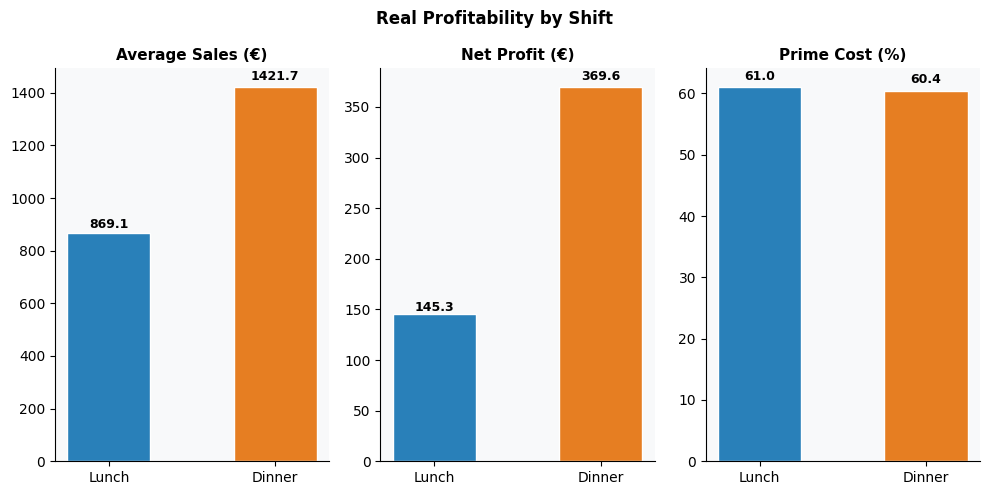


  Recommendations:
  - Compare margins, not just gross sales.
  - A shift can generate more revenue but cost proportionally more,
    resulting in a lower real profit.
  - Focus on the net margin % column - that is the real performance indicator.


In [6]:
# CALCULATION 
# agg() computes multiple metrics at once per shift.
# We need sales, profit and prime cost together because
# higher sales do not always mean a better real margin.
profitability = df.groupby("shift").agg(
    avg_sales        = ("sales_eur",       "mean"),
    avg_net_profit   = ("net_profit_eur",  "mean"),
    avg_prime_cost   = ("prime_cost_pct",  "mean"),
    avg_covers       = ("covers",          "mean"),
).round(2)

# Net margin % = net profit / sales for each shift
profitability["net_margin_pct"] = (
    profitability["avg_net_profit"] / profitability["avg_sales"] * 100
).round(1)

print("=" * 55)
print(" Real Profitability by Shift")
print("=" * 55)
print(f"\n{profitability.to_string()}")
print(f"\n  Most profitable shift (€/shift): {profitability['avg_net_profit'].idxmax()}")
print(f"  Best net margin (%): {profitability['net_margin_pct'].idxmax()}")

# CHART 
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

metrics = ["avg_sales", "avg_net_profit", "avg_prime_cost"]
titles  = ["Average Sales (€)", "Net Profit (€)", "Prime Cost (%)"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals = [profitability.loc["Lunch",  metric],
            profitability.loc["Dinner", metric]]
    axes[i].bar(
        ["Lunch", "Dinner"], vals,
        color=[COLORS["blue"], COLORS["orange"]],
        edgecolor="white", width=0.5
    )
    axes[i].set_title(title, fontweight="bold", fontsize=11)
    for j, v in enumerate(vals):
        axes[i].text(j, v + abs(v) * 0.02, f"{v:.1f}",
                     ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Real Profitability by Shift",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/04_profitability_by_shift.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS
print(f"\n  Recommendations:")
print(f"  - Compare margins, not just gross sales.")
print(f"  - A shift can generate more revenue but cost proportionally more,")
print(f"    resulting in a lower real profit.")
print(f"  - Focus on the net margin % column - that is the real performance indicator.")

### 5. RevPASH - Space Efficiency

RevPASH - Space Efficiency

  Minimum healthy threshold: €8.0/seat/hour

  Dinner: €6.32/seat/h = Below threshold
  Lunch: €4.97/seat/h = Below threshold

  Shifts below threshold: 940 (78.3% of total)


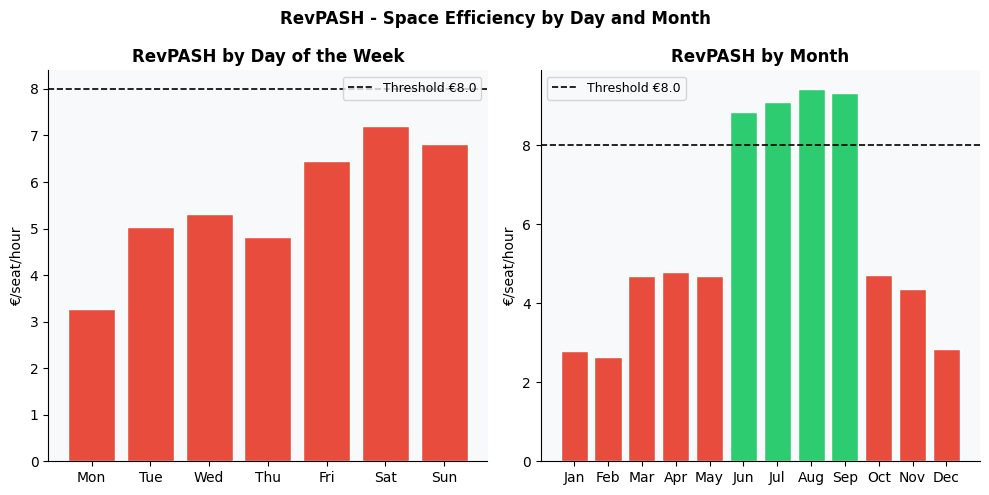


  Recommendations:
 - ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'] do not reach the profitability threshold.
   Consider launching promotions or reducing operating costs on those days.
 - 78.3% of all shifts are below the threshold.
   Each of those hours costs money instead of generating it.
 - RevPASH is more honest than occupancy: a full restaurant
   with a low ticket can be less efficient than a half-full one.


In [7]:
# REVPASH DEFINITION 
# RevPASH = Revenue Per Available Seat Hour
# Measures real space efficiency: sales / (seats × service hours).
# A fully packed restaurant with a low ticket can have a worse RevPASH
# than a half-full one with a high ticket.
REVPASH_THRESHOLD = 8.0   # Minimum healthy threshold for hospitality in Málaga

MONTH_LABELS = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
DAY_ORDER    = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
DAY_SHORT    = {"Monday":"Mon","Tuesday":"Tue","Wednesday":"Wed",
                "Thursday":"Thu","Friday":"Fri","Saturday":"Sat","Sunday":"Sun"}

# CALCULATION 
revpash_shift = df.groupby("shift")["revpash_eur"].mean()
revpash_day   = df.groupby("day_of_week")["revpash_eur"].mean().reindex(DAY_ORDER)
revpash_month = df.groupby("month")["revpash_eur"].mean()

# Shifts below the healthy threshold
below_threshold     = df[df["revpash_eur"] < REVPASH_THRESHOLD]
pct_below_threshold = len(below_threshold) / len(df) * 100

print("=" * 55)
print("RevPASH - Space Efficiency")
print("=" * 55)
print(f"\n  Minimum healthy threshold: €{REVPASH_THRESHOLD}/seat/hour\n")

for shift, val in revpash_shift.items():
    status = "Above" if val >= REVPASH_THRESHOLD else "Below"
    print(f"  {shift}: €{val:.2f}/seat/h = {status} threshold")

print(f"\n  Shifts below threshold: {len(below_threshold)} ({pct_below_threshold:.1f}% of total)")

# CHART 
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: RevPASH by day of the week
day_colors = [
    COLORS["green"] if v >= REVPASH_THRESHOLD else COLORS["red"]
    for v in revpash_day.values
]
axes[0].bar(
    [DAY_SHORT[d] for d in DAY_ORDER],
    revpash_day.values,
    color=day_colors, edgecolor="white"
)
axes[0].axhline(REVPASH_THRESHOLD, color="black",
                linestyle="--", linewidth=1.2,
                label=f"Threshold €{REVPASH_THRESHOLD}")
axes[0].set_title("RevPASH by Day of the Week", fontweight="bold")
axes[0].set_ylabel("€/seat/hour")
axes[0].legend(fontsize=9)

# Right: RevPASH by month
month_colors = [
    COLORS["green"] if v >= REVPASH_THRESHOLD else COLORS["red"]
    for v in revpash_month.values
]
axes[1].bar(
    [MONTH_LABELS[m] for m in revpash_month.index],
    revpash_month.values,
    color=month_colors, edgecolor="white"
)
axes[1].axhline(REVPASH_THRESHOLD, color="black",
                linestyle="--", linewidth=1.2,
                label=f"Threshold €{REVPASH_THRESHOLD}")
axes[1].set_title("RevPASH by Month", fontweight="bold")
axes[1].set_ylabel("€/seat/hour")
axes[1].legend(fontsize=9)

plt.suptitle("RevPASH - Space Efficiency by Day and Month",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/05_revpash.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS
days_below = [DAY_SHORT[d] for d in DAY_ORDER
              if d in revpash_day.index and revpash_day[d] < REVPASH_THRESHOLD]

print(f"\n  Recommendations:")
if days_below:
    print(f" - {days_below} do not reach the profitability threshold.")
    print(f"   Consider launching promotions or reducing operating costs on those days.")
print(f" - {pct_below_threshold:.1f}% of all shifts are below the threshold.")
print(f"   Each of those hours costs money instead of generating it.")
print(f" - RevPASH is more honest than occupancy: a full restaurant")
print(f"   with a low ticket can be less efficient than a half-full one.")

### 6. Real Cost of Food Waste

 Real Cost of Food Waste

  Your waste %: 8.0%
  Sector benchmark: < 5%
  Status: Above benchmark

  Average monthly waste cost: €2,746/month
  Estimated annual cost: €32,954/year

 If you reach the benchmark (5.0%):
 You would save €12,318/year
 (€1,026/month)


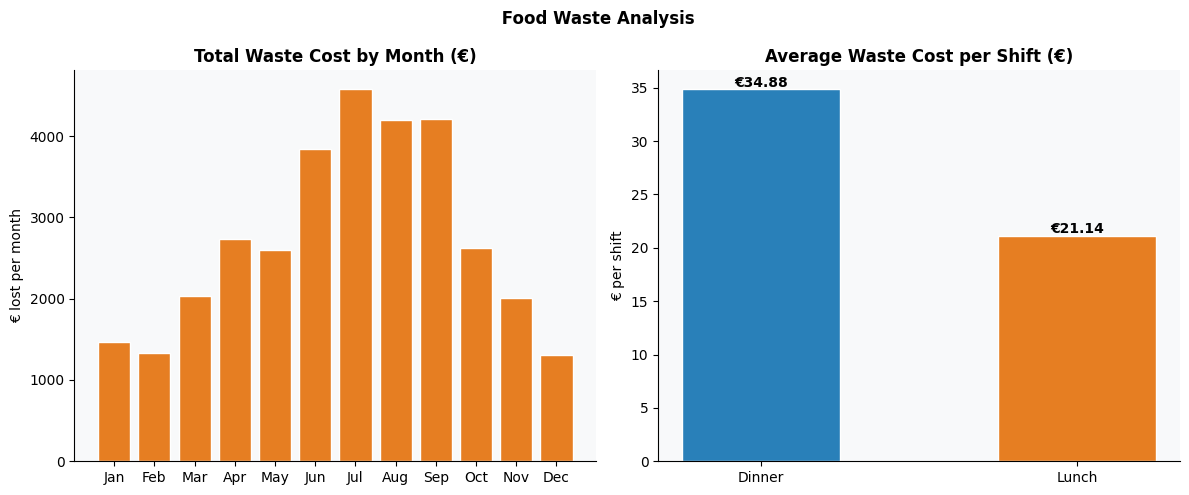


   Recommendations:
  - Implement a weekly waste tracking log by product category.
  - The Dinner shift generates the most waste: review
     purchasing quantities and storage practices for that shift.
  - Reaching the 5.0% benchmark would recover
     €1,026/month in pure margin — no price increase needed.


In [8]:
# CALCULATION 
# Waste in euros = food cost (€) × waste percentage
# This converts the percentage into real money lost per shift.
df["waste_eur"] = (df["food_cost_eur"] * df["waste_pct"] / 100).round(2)

MONTH_LABELS    = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                   7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
WASTE_BENCHMARK = 5.0   # Healthy sector benchmark: below 5%

waste_by_month  = df.groupby("month")["waste_eur"].sum()
waste_by_shift  = df.groupby("shift")["waste_eur"].mean()
total_waste     = df["waste_eur"].sum()
avg_waste_pct   = df["waste_pct"].mean()
n_months        = df["month"].nunique()
avg_waste_month = total_waste / n_months

# Potential savings if the sector benchmark is reached
savings = (avg_waste_pct - WASTE_BENCHMARK) / 100 * df["food_cost_eur"].sum()

print("=" * 55)
print(" Real Cost of Food Waste")
print("=" * 55)
print(f"\n  Your waste %: {avg_waste_pct:.1f}%")
print(f"  Sector benchmark: < {WASTE_BENCHMARK:.0f}%")
print(f"  Status: {'Under control' if avg_waste_pct <= WASTE_BENCHMARK else 'Above benchmark'}")
print(f"\n  Average monthly waste cost: €{avg_waste_month:,.0f}/month")
print(f"  Estimated annual cost: €{avg_waste_month * 12:,.0f}/year")

if savings > 0:
    print(f"\n If you reach the benchmark ({WASTE_BENCHMARK}%):")
    print(f" You would save €{savings / n_months * 12:,.0f}/year")
    print(f" (€{savings / n_months:,.0f}/month)")

# CHART 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: total waste cost per month
axes[0].bar(
    [MONTH_LABELS[m] for m in waste_by_month.index],
    waste_by_month.values,
    color=COLORS["orange"], edgecolor="white"
)
axes[0].set_title("Total Waste Cost by Month (€)", fontweight="bold")
axes[0].set_ylabel("€ lost per month")

# Right: average waste cost per shift
axes[1].bar(
    waste_by_shift.index, waste_by_shift.values,
    color=[COLORS["blue"], COLORS["orange"]],
    edgecolor="white", width=0.5
)
axes[1].set_title("Average Waste Cost per Shift (€)", fontweight="bold")
axes[1].set_ylabel("€ per shift")
for i, (shift, v) in enumerate(waste_by_shift.items()):
    axes[1].text(i, v + 0.2, f"€{v:.2f}", ha="center", fontweight="bold")

plt.suptitle(" Food Waste Analysis",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/06_food_waste.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS 
worst_shift = waste_by_shift.idxmax()
print(f"\n   Recommendations:")
print(f"  - Implement a weekly waste tracking log by product category.")
print(f"  - The {worst_shift} shift generates the most waste: review")
print(f"     purchasing quantities and storage practices for that shift.")
if savings > 0:
    print(f"  - Reaching the {WASTE_BENCHMARK}% benchmark would recover")
    print(f"     €{savings / n_months:,.0f}/month in pure margin — no price increase needed.")

### 7. Average Ticket by Booking Channel

 Which Channel Brings the Best-Spending Guest?

  Channel            Avg Ticket     Avg Covers     Records
  -------------------------------------------------------
  🏆 Website          € 23.38            47            95
     WhatsApp         € 23.29            49           146
     Google Maps      € 23.05            46           234
     Phone            € 22.80            47           326
  🔴 Walk-in          € 22.78            45           399

  Gap between best and worst channel: €0.60/guest


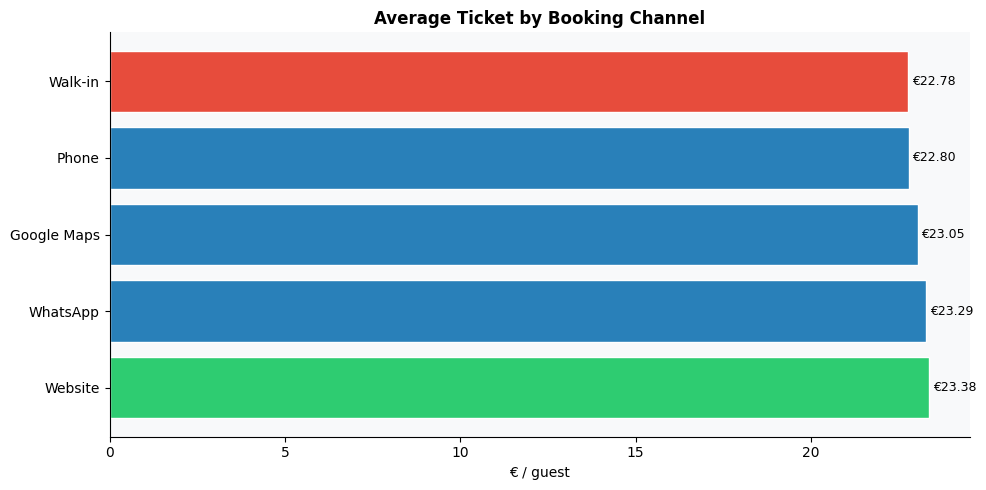


  Recommendations:
   - Website brings the highest-spending guest.
     Prioritize it in your marketing and reservation strategy.
   - Walk-in brings the lowest-spending guest.
     Evaluate whether the volume compensates the lower ticket.


In [9]:
# CALCULATION 

ticket_by_channel = df.groupby("booking_channel").agg(
    avg_ticket    = ("avg_ticket_eur", "mean"),
    avg_covers    = ("covers",         "mean"),
    record_count  = ("sales_eur",      "count"),
).round(2).sort_values("avg_ticket", ascending=False)

best_channel  = ticket_by_channel["avg_ticket"].idxmax()
worst_channel = ticket_by_channel["avg_ticket"].idxmin()

print("=" * 55)
print(" Which Channel Brings the Best-Spending Guest?")
print("=" * 55)
print(f"\n  {'Channel':<18} {'Avg Ticket':<14} {'Avg Covers':<14} {'Records'}")
print(f"  {'-'*55}")
for channel, row in ticket_by_channel.iterrows():
    icon = "🏆" if channel == best_channel else "🔴" if channel == worst_channel else "  "
    print(f"  {icon} {channel:<16} €{row['avg_ticket']:>6.2f}        "
          f"{row['avg_covers']:>6.0f}         {row['record_count']:>5.0f}")

diff = ticket_by_channel["avg_ticket"].max() - ticket_by_channel["avg_ticket"].min()
print(f"\n  Gap between best and worst channel: €{diff:.2f}/guest")

# CHART 
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [
    COLORS["green"] if v == ticket_by_channel["avg_ticket"].max()
    else COLORS["red"] if v == ticket_by_channel["avg_ticket"].min()
    else COLORS["blue"]
    for v in ticket_by_channel["avg_ticket"].values
]
ax.barh(ticket_by_channel.index, ticket_by_channel["avg_ticket"],
        color=bar_colors, edgecolor="white")
ax.set_title("Average Ticket by Booking Channel",
             fontweight="bold", fontsize=12)
ax.set_xlabel("€ / guest")
for i, v in enumerate(ticket_by_channel["avg_ticket"].values):
    ax.text(v + 0.1, i, f"€{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/07_ticket_by_channel.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS
print(f"\n  Recommendations:")
print(f"   - {best_channel} brings the highest-spending guest.")
print(f"     Prioritize it in your marketing and reservation strategy.")
print(f"   - {worst_channel} brings the lowest-spending guest.")
print(f"     Evaluate whether the volume compensates the lower ticket.")


### 8. Hypothesis: Outdoor Temperature vs Covers

 Hypothesis: Outdoor Temperature vs Covers

  H0: No correlation between temperature and covers
  H1: A significant correlation exists

  Pearson r = 0.509
  p-value   = 0.000000
  Threshold = 0.05

  H0 REJECTED - positive correlation 
  More heat = more guests (consistent with Málaga summer tourism)
  Every extra 1°C  ~5.1 additional covers

  Staff planning table by temperature range:

  Range        Covers     Staff      Recommendation
  ------------------------------------------------------------
  < 15°C           33        4       Reduce 1 staff 
  15–20°C          36        4       Reduce 1 staff 
  20–25°C          43        5       Stable staffing
  25–30°C          52        6       Add 1 staff
  > 30°C           60        7       Add 1 staff

  ─── RECOMMENDATIONS ────────────────────────────────

  1. Temperature reliably predicts footfall (positive direction).
     This restaurant fills up more in hot weather (Málaga tourism effect).
     Plan staffing reinforcements for 

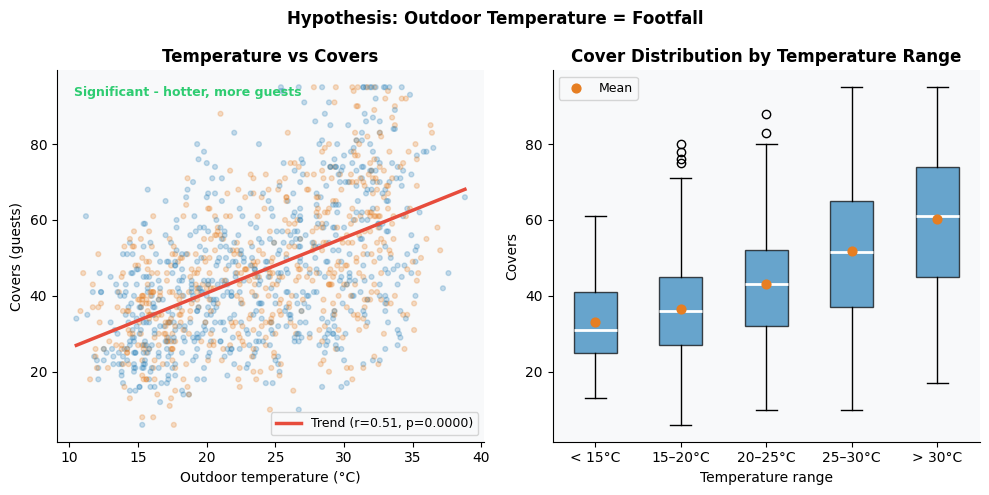

In [10]:
# ── HYPOTHESIS TEST ───────────────────────────────────────────────────────────
# Pearson correlation between outdoor temperature and number of covers.
# H0: no correlation exists between temperature and covers
# H1: a statistically significant correlation exists (any direction)
# If p < 0.05 we reject H0 with 95% confidence.
pearson_r, pearson_p = stats.pearsonr(df["temperature_c"], df["covers"])

print("=" * 55)
print(" Hypothesis: Outdoor Temperature vs Covers")
print("=" * 55)
print(f"\n  H0: No correlation between temperature and covers")
print(f"  H1: A significant correlation exists\n")
print(f"  Pearson r = {pearson_r:.3f}")
print(f"  p-value   = {pearson_p:.6f}")
print(f"  Threshold = 0.05\n")

if pearson_p < 0.05:
    if pearson_r > 0:
        print(f"  H0 REJECTED - positive correlation ")
        print(f"  More heat = more guests (consistent with Málaga summer tourism)")
        print(f"  Every extra 1°C  ~{pearson_r * 10:.1f} additional covers")
        correlation_direction = "positive"
    else:
        print(f"  H0 REJECTED - negative correlation ")
        print(f"  More heat = FEWER guests")
        print(f"  Every extra 1°C = ~{abs(pearson_r) * 10:.1f} fewer covers")
        correlation_direction = "negative"
else:
    print(f"  H0 NOT rejected - temperature does not predict footfall")
    correlation_direction = "none"

# STAFF PLANNING TABLE BY TEMPERATURE RANGE 
# pd.cut splits continuous temperature into 5 discrete groups.
df["temp_range"] = pd.cut(
    df["temperature_c"],
    bins=[0, 15, 20, 25, 30, 45],
    labels=["< 15°C", "15–20°C", "20–25°C", "25–30°C", "> 30°C"]
)

temp_stats = df.groupby("temp_range", observed=True).agg(
    avg_covers = ("covers",      "mean"),
    avg_staff  = ("staff_count", "mean"),
    avg_sales  = ("sales_eur",   "mean"),
)
# Round staff to nearest integer - no one has 4.2 employees
temp_stats["avg_staff"]  = temp_stats["avg_staff"].round(0).astype(int)
temp_stats["avg_covers"] = temp_stats["avg_covers"].round(1)
temp_stats["avg_sales"]  = temp_stats["avg_sales"].round(2)

overall_avg_covers = temp_stats["avg_covers"].mean()

print(f"\n  Staff planning table by temperature range:\n")
print(f"  {'Range':<12} {'Covers':<10} {'Staff':<10} {'Recommendation'}")
print(f"  {'-'*60}")

staff_recommendations = {}
for temp_range, row in temp_stats.iterrows():
    if pearson_r < 0:
        # Negative correlation: colder = more guests - reinforce in cold ranges
        if row["avg_covers"] > overall_avg_covers * 1.15:
            rec = "Add 1 staff"
        elif row["avg_covers"] < overall_avg_covers * 0.85:
            rec = " Reduce 1 staff"
        else:
            rec = "Stable staffing"
    else:
        # Positive correlation: hotter = more guests - reinforce in hot ranges
        if row["avg_covers"] > overall_avg_covers * 1.15:
            rec = "Add 1 staff"
        elif row["avg_covers"] < overall_avg_covers * 0.85:
            rec = "Reduce 1 staff "
        else:
            rec = "Stable staffing"

    staff_recommendations[str(temp_range)] = rec
    print(f"  {str(temp_range):<12} {row['avg_covers']:>6.0f}     "
          f"{int(row['avg_staff']):>4d}       {rec}")

# Lists of ranges that need action
ranges_reinforce = [rk for rk, rec in staff_recommendations.items() if "Add"    in rec]
ranges_reduce    = [rk for rk, rec in staff_recommendations.items() if "Reduce" in rec]

# ── RECOMMENDATIONS ───────────────────────────────────────────────────────────
print(f"\n  ─── RECOMMENDATIONS ────────────────────────────────")

if pearson_p < 0.05 and pearson_r > 0:
    print(f"\n  1. Temperature reliably predicts footfall (positive direction).")
    print(f"     This restaurant fills up more in hot weather (Málaga tourism effect).")
    print(f"     Plan staffing reinforcements for spring and summer.")
elif pearson_p < 0.05 and pearson_r < 0:
    print(f"\n  1. Temperature reliably predicts footfall (negative direction).")
    print(f"     This restaurant fills up more in cooler temperatures.")
    print(f"     Plan staffing reinforcements for autumn and winter.")
else:
    print(f"\n  1. Temperature does not predict footfall in this restaurant.")
    print(f"     Look for other drivers: local events, public holidays, season.")

if ranges_reinforce:
    print(f"\n  2. Reinforce staffing in: {', '.join(ranges_reinforce)}")
    print(f"     Covers in those ranges exceed the average by 15% or more.")

if ranges_reduce:
    print(f"\n  3. Consider reducing staff in: {', '.join(ranges_reduce)}")
    savings = 4 * 30 * 8 * 8   # shifts/day × days × hours × €/hour (approx)
    print(f"     Estimated monthly saving: ~€{savings:,.0f}")

if pearson_r > 0:
    print(f"\n  4. Plan May staffing in April.")
    print(f"     The heat arrives before reinforcements if you wait too long.")
else:
    print(f"\n  4. Plan October staffing in September.")
    print(f"     The cold season picks up faster than expected.")

# Variable saved for use in P2 (staff planning by month)
print(f"\n  correlation_direction = '{correlation_direction}' saved for no.10")

# CHARTS 
m_reg, b_reg = np.polyfit(df["temperature_c"], df["covers"], 1)
x_line       = np.linspace(df["temperature_c"].min(), df["temperature_c"].max(), 100)
dot_colors   = np.where(df["shift"] == "Dinner", COLORS["orange"], COLORS["blue"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: scatterplot temperature vs covers with trend line
axes[0].scatter(df["temperature_c"], df["covers"],
                c=dot_colors, alpha=0.25, s=12)
axes[0].plot(x_line, m_reg * x_line + b_reg,
             color=COLORS["red"], linewidth=2.5,
             label=f"Trend (r={pearson_r:.2f}, p={pearson_p:.4f})")
axes[0].set_title("Temperature vs Covers", fontweight="bold")
axes[0].set_xlabel("Outdoor temperature (°C)")
axes[0].set_ylabel("Covers (guests)")

result_label = ("Significant - hotter, more guests"   if pearson_p < 0.05 and pearson_r > 0
                else "Significant - cooler, more guests" if pearson_p < 0.05
                else "Not significant")
axes[0].text(0.04, 0.93, result_label, transform=axes[0].transAxes,
             color=COLORS["green"] if pearson_p < 0.05 else COLORS["red"],
             fontweight="bold", fontsize=9)
axes[0].legend(fontsize=9)

# Right: boxplot of covers per temperature range + mean marker
TEMP_RANGES = ["< 15°C", "15–20°C", "20–25°C", "25–30°C", "> 30°C"]
groups    = [df[df["temp_range"] == rk]["covers"].values
             for rk in TEMP_RANGES if len(df[df["temp_range"] == rk]) > 0]
labels    = [rk for rk in TEMP_RANGES if len(df[df["temp_range"] == rk]) > 0]

bp = axes[1].boxplot(groups, labels=labels, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor(COLORS["blue"])
    patch.set_alpha(0.7)

# Orange dot = mean per range (more informative than median alone)
means = [df[df["temp_range"] == rk]["covers"].mean() for rk in labels]
axes[1].scatter(range(1, len(labels) + 1), means,
                color=COLORS["orange"], zorder=5, s=40, label="Mean")
axes[1].legend(fontsize=9)
axes[1].set_title("Cover Distribution by Temperature Range", fontweight="bold")
axes[1].set_ylabel("Covers")
axes[1].set_xlabel("Temperature range")

plt.suptitle("Hypothesis: Outdoor Temperature = Footfall",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/08_temperature_hypothesis.png", dpi=150, bbox_inches="tight")
plt.show()

## Advanced Analysis

### 9. Best and Worst Operational Decisions

Best and Worst Operational Decisions

  TOP 3 BEST (most profitable):
    Dinner - Saturday                    €  533.31
    Dinner - Friday                      €  483.41
    Dinner - Sunday                      €  444.22

  TOP 3 WORST (least profitable):
    Lunch - Wednesday                    €  110.87
    Lunch - Tuesday                      €  105.25
    Lunch - Monday                       €   -2.55

  The worst combination generates €-133/year.
  Removing it would improve annual results by €133.


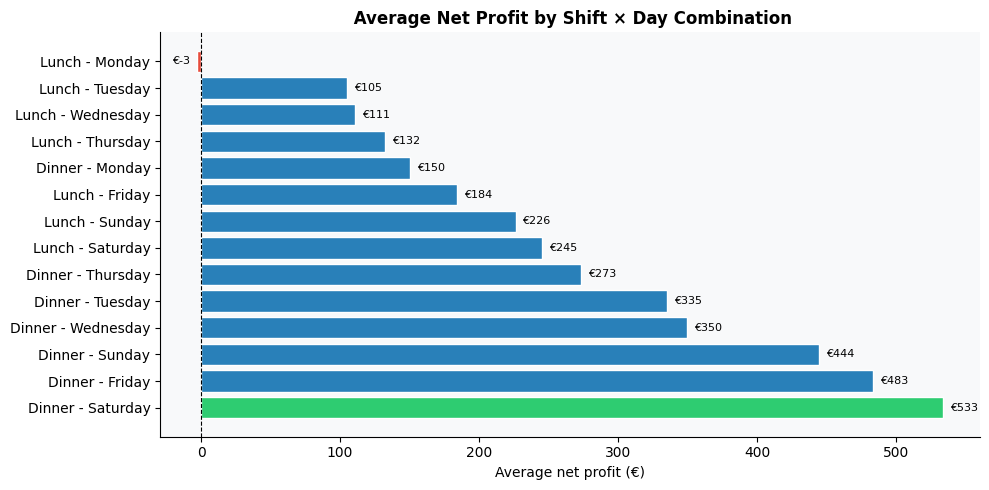


  Recommendations:
  - Protect and maximize: Dinner - Saturday
     It is your highest-profit slot at €533.31/shift.
  - Reconsider: Lunch - Monday
     It costs the business €133/year.
 Options: close that slot, convert to a special event, or renegotiate costs.


In [11]:
# CALCULATION 
# Average net profit per shift × day combination.
# Each combination represents one opening decision.
# This reveals which specific slots are worth keeping and which to reconsider.
DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

decision_df = (
    df.groupby(["shift", "day_of_week"])["net_profit_eur"]
    .mean()
    .reset_index()
    .round(2)
)
decision_df["combination"] = decision_df["shift"] + " - " + decision_df["day_of_week"]
decision_df = decision_df.sort_values("net_profit_eur", ascending=False)

print("=" * 55)
print("Best and Worst Operational Decisions")
print("=" * 55)
print(f"\n  TOP 3 BEST (most profitable):")
for _, row in decision_df.head(3).iterrows():
    print(f"    {row['combination']:<35}  €{row['net_profit_eur']:>8,.2f}")

print(f"\n  TOP 3 WORST (least profitable):")
for _, row in decision_df.tail(3).iterrows():
    print(f"    {row['combination']:<35}  €{row['net_profit_eur']:>8,.2f}")

# Annual impact of the worst combination
worst       = decision_df.iloc[-1]
annual_impact = worst["net_profit_eur"] * 52
print(f"\n  The worst combination generates €{annual_impact:,.0f}/year.")
if annual_impact < 0:
    print(f"  Removing it would improve annual results by €{abs(annual_impact):,.0f}.")

# CHART 
# Green  = best combination
# Red    = worst combination
# Blue   = positive profit
# Orange = negative profit (losing money)
bar_colors = [
    COLORS["green"]  if v == decision_df["net_profit_eur"].max()
    else COLORS["red"]    if v == decision_df["net_profit_eur"].min()
    else COLORS["blue"]   if v > 0
    else COLORS["orange"]
    for v in decision_df["net_profit_eur"].values
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    decision_df["combination"],
    decision_df["net_profit_eur"],
    color=bar_colors, edgecolor="white"
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(" Average Net Profit by Shift × Day Combination",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Average net profit (€)")

# Value labels at the end of each bar
for i, v in enumerate(decision_df["net_profit_eur"].values):
    ax.text(v + (5 if v >= 0 else -5), i,
            f"€{v:,.0f}", va="center", fontsize=8,
            ha="left" if v >= 0 else "right")

plt.tight_layout()
plt.savefig("outputs/09_best_worst_decisions.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS
best = decision_df.iloc[0]
print(f"\n  Recommendations:")
print(f"  - Protect and maximize: {best['combination']}")
print(f"     It is your highest-profit slot at €{best['net_profit_eur']:,.2f}/shift.")
if annual_impact < 0:
    print(f"  - Reconsider: {worst['combination']}")
    print(f"     It costs the business €{abs(annual_impact):,.0f}/year.")
    print(f" Options: close that slot, convert to a special event, or renegotiate costs.")

### 10. Monthly Staff Planning

correlation_direction = 'positive' (loaded from no.8)

 Monthly Staff Planning

  Annual average covers : 47 guests/shift
  Reinforce threshold   : > 54 covers (+15%)
  Reduce threshold      : < 40 covers (−15%)

  Consistent with no.8: positive correlation confirmed.
  Warmer months (summer tourism) drive higher footfall.

  Month  Temp     Covers     Staff      Decision
  ------------------------------------------------------------------------
  Jan    14.8°C       34        4       Reduce staff        
  Feb    16.0°C       32        4       Reduce staff        
  Mar    20.0°C       44        5       Stable staffing
  Apr    23.8°C       45        5       Stable staffing
  May    28.5°C       44        5       Stable staffing
  Jun    31.6°C       59        7       Hire reinforcement  
  Jul    33.1°C       62        7       Hire reinforcement  
  Aug    31.7°C       63        7       Hire reinforcement  
  Sep    28.3°C       61        7       Hire reinforcement  
  Oct    23.7°C 

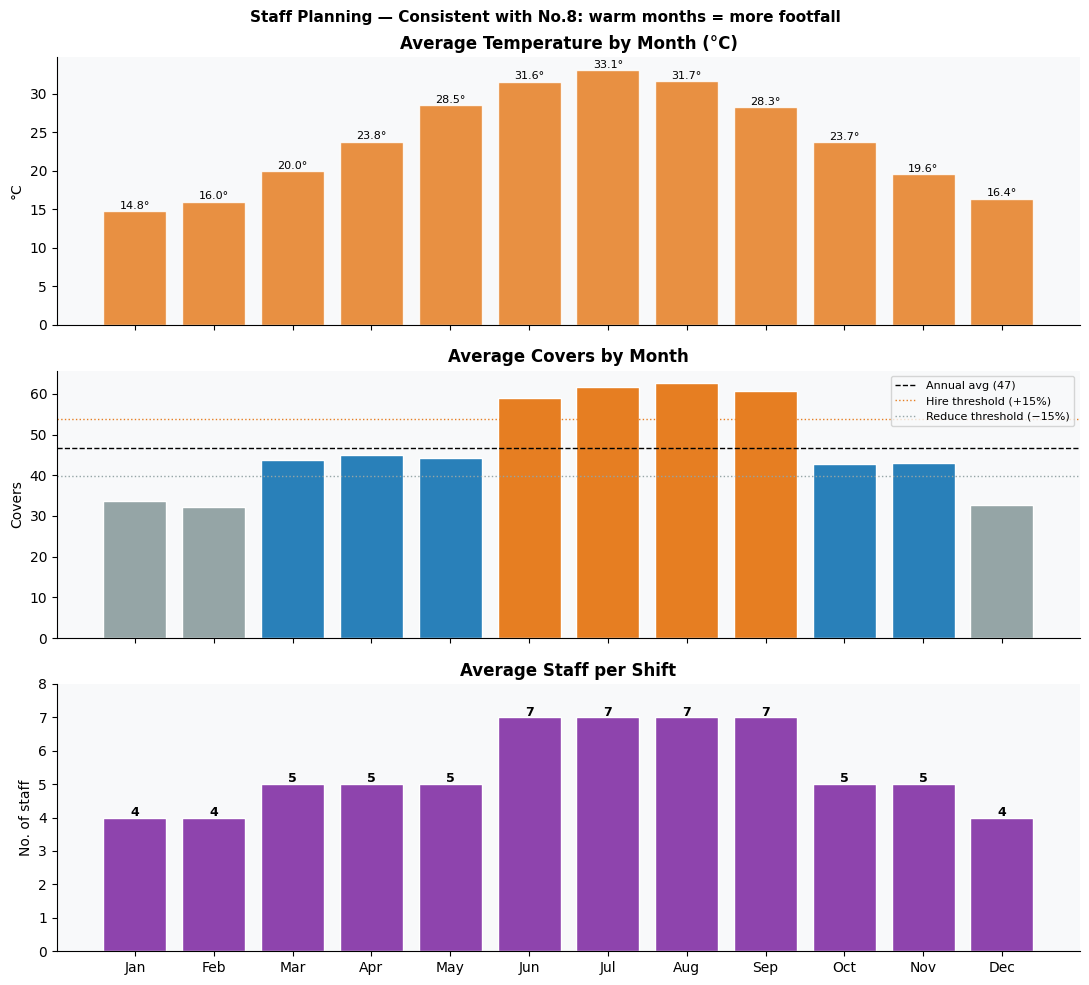

In [12]:
# DEPENDENCY CHECK
# This fragment depends on 'correlation_direction' calculated in no.8.
# Always run no.8 before running this fragment.
if "correlation_direction" not in dir():
    print(" WARNING: run no.8 first to calculate correlation_direction.")
    correlation_direction = "none"
else:
    print(f"correlation_direction = '{correlation_direction}' (loaded from no.8)")

MONTH_LABELS = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

# CALCULATION 
# Average temperature per month - added to the staffing table so the client
# can see the relationship: temperature - covers - staff needed.
avg_temp_by_month = df.groupby("month")["temperature_c"].mean().round(1)

staffing = df.groupby("month").agg(
    avg_covers = ("covers",        "mean"),
    avg_staff  = ("staff_count",   "mean"),
    avg_profit = ("net_profit_eur","mean"),
)
# Round staff to nearest integer — no one has 4.2 employees
staffing["avg_staff"]  = staffing["avg_staff"].round(0).astype(int)
staffing["avg_covers"] = staffing["avg_covers"].round(1)
staffing["avg_profit"] = staffing["avg_profit"].round(2)
staffing["avg_temp"]   = avg_temp_by_month

overall_avg_covers = staffing["avg_covers"].mean()

# STAFFING DECISION - COHERENT WITH M5 RESULT 
# The recommendation text explains the WHY using what no.8. found.
# This is the key link between the two fragments.
def staffing_decision(row):
    covers = row["avg_covers"]
    if covers > overall_avg_covers * 1.15:
        if correlation_direction == "positive":
            return "Hire reinforcement  "
        elif correlation_direction == "negative":
            return "Hire reinforcement  "
        else:
            return "Hire reinforcement  "
    elif covers < overall_avg_covers * 0.85:
        if correlation_direction == "positive":
            return "Reduce staff        "
        elif correlation_direction == "negative":
            return "Reduce staff        "
        else:
            return "Reduce staff        "
    else:
        return "Stable staffing"

staffing["decision"] = staffing.apply(staffing_decision, axis=1)

# PRINT TABLE
print(f"\n{'=' * 50}")
print(f" Monthly Staff Planning")
print(f"{'=' * 50}")
print(f"\n  Annual average covers : {overall_avg_covers:.0f} guests/shift")
print(f"  Reinforce threshold   : > {overall_avg_covers * 1.15:.0f} covers (+15%)")
print(f"  Reduce threshold      : < {overall_avg_covers * 0.85:.0f} covers (−15%)")

if correlation_direction == "positive":
    print(f"\n  Consistent with no.8: positive correlation confirmed.")
    print(f"  Warmer months (summer tourism) drive higher footfall.")
elif correlation_direction == "negative":
    print(f"\n  Consistent with no.8: negative correlation confirmed.")
    print(f"  Cooler months drive higher footfall.")
else:
    print(f"\n  No.8 found no temperature correlation - planning based on historical data.")

print(f"\n  {'Month':<6} {'Temp':<8} {'Covers':<10} {'Staff':<10} {'Decision'}")
print(f"  {'-'*72}")
for month, row in staffing.iterrows():
    print(f"  {MONTH_LABELS[month]:<6} {row['avg_temp']:>4.1f}°C   "
          f"{row['avg_covers']:>6.0f}     "
          f"{int(row['avg_staff']):>4d}       "
          f"{row['decision']}")

# Month lists by decision
months_hire   = [MONTH_LABELS[mk] for mk, rec in staffing["decision"].items()
                 if "Hire"   in rec]
months_reduce = [MONTH_LABELS[mk] for mk, rec in staffing["decision"].items()
                 if "Reduce" in rec]

print(f"\n  Months to hire reinforcement : {months_hire}")
print(f"    Months to reduce staff       : {months_reduce}")

# RECOMMENDATIONS
print(f"\n Recommendations: ")
if months_hire:
    print(f"\n  1. Hire reinforcement in {months_hire}.")
    if correlation_direction == "positive":
        print(f"     These are the warmest months. No.8 confirmed that heat")
        print(f"     drives more footfall in this restaurant (tourism effect).")
    elif correlation_direction == "negative":
        print(f"     These are the coolest months. No.8 confirmed that cold")
        print(f"     drives more footfall in this restaurant.")
    else:
        print(f"     These months show the highest historical footfall.")
    print(f"     Hire at least 3 weeks in advance.")

if months_reduce:
    print(f"\n  2. Reduce staff in {months_reduce}.")
    if correlation_direction == "positive":
        print(f"     These are the coolest months with lower tourist footfall.")
    elif correlation_direction == "negative":
        print(f"     These are the warmest months with lower footfall.")
    else:
        print(f"     These months show the lowest historical footfall.")
    print(f"     Use this period to schedule team holidays.")

print(f"\n  3. Annual average net profit: €{staffing['avg_profit'].mean():.2f}/shift.")
print(f"     In reinforcement months, verify that the revenue increase")
print(f"     covers the additional staffing cost before hiring.")

if correlation_direction != "none":
    print(f"\n  4. Check the weather forecast every Monday.")
    print(f"     No.8 confirmed temperature predicts footfall.")
    print(f"     Use it to fine-tune staffing week by week.")

# CHARTS 
# Dynamic title based on correlation direction
if correlation_direction == "positive":
    chart_note = "Consistent with No.8: warm months = more footfall"
elif correlation_direction == "negative":
    chart_note = "Consistent with No.8: cool months = more footfall"
else:
    chart_note = "Based on historical data — no temperature correlation found"

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

# Top chart: average temperature per month
axes[0].bar([MONTH_LABELS[m] for m in staffing.index], staffing["avg_temp"],
            color=COLORS["orange"], edgecolor="white", alpha=0.85)
axes[0].set_title("Average Temperature by Month (°C)", fontweight="bold")
axes[0].set_ylabel("°C")
for i, (month, row) in enumerate(staffing.iterrows()):
    axes[0].text(i, row["avg_temp"] + 0.3,
                 f"{row['avg_temp']:.1f}°", ha="center", fontsize=8)

# Middle chart: average covers per month — color coded by decision
cover_colors = [
    COLORS["orange"] if "Hire"   in v
    else COLORS["gray"]   if "Reduce" in v
    else COLORS["blue"]
    for v in staffing["decision"]
]
axes[1].bar([MONTH_LABELS[m] for m in staffing.index], staffing["avg_covers"],
            color=cover_colors, edgecolor="white")
axes[1].axhline(overall_avg_covers, color="black", linestyle="--",
                linewidth=1, label=f"Annual avg ({overall_avg_covers:.0f})")
axes[1].axhline(overall_avg_covers * 1.15, color=COLORS["orange"],
                linestyle=":", linewidth=1, label="Hire threshold (+15%)")
axes[1].axhline(overall_avg_covers * 0.85, color=COLORS["gray"],
                linestyle=":", linewidth=1, label="Reduce threshold (−15%)")
axes[1].set_title("Average Covers by Month", fontweight="bold")
axes[1].set_ylabel("Covers")
axes[1].legend(fontsize=8)

# Bottom chart: average staff per month with integer labels
axes[2].bar([MONTH_LABELS[m] for m in staffing.index], staffing["avg_staff"],
            color=COLORS["purple"], edgecolor="white")
for i, (month, row) in enumerate(staffing.iterrows()):
    axes[2].text(i, int(row["avg_staff"]) + 0.05,
                 str(int(row["avg_staff"])),
                 ha="center", fontsize=9, fontweight="bold")
axes[2].set_title("Average Staff per Shift", fontweight="bold")
axes[2].set_ylabel("No. of staff")
axes[2].set_ylim(0, staffing["avg_staff"].max() + 1)

plt.suptitle(f"Staff Planning — {chart_note}",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/10_staff_planning.png", dpi=150, bbox_inches="tight")
plt.show()

### 11. Prime Cost Trend — Last 6 Months

 Prime Cost Trend — Last 6 Months

  Healthy limit : < 65.0%


  Trend: IMPROVING (-0.07% per month)


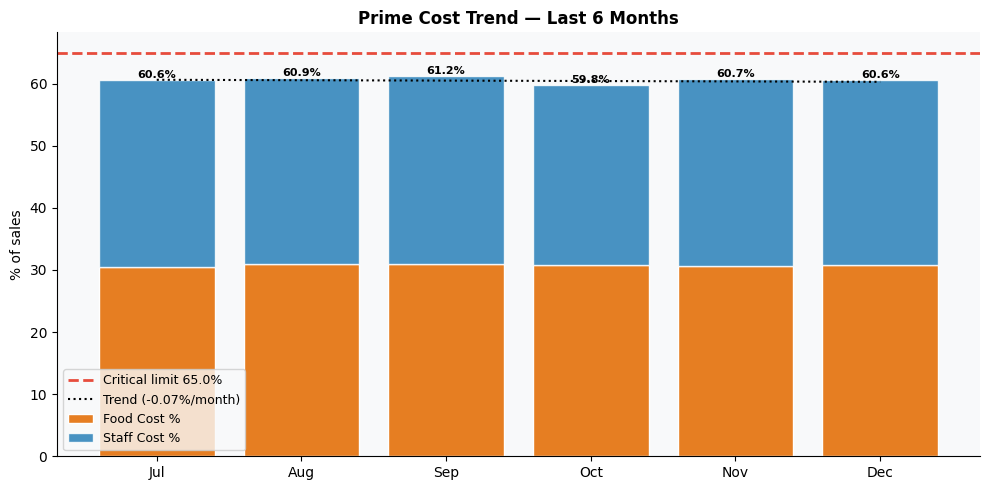


  Recommendations:
  - The prime cost is stable. Monitor monthly to catch early deviations.


In [13]:
# CONFIGURATION
PRIME_COST_LIMIT = 65.0   # Critical threshold: above this the business loses profitability

MONTH_LABELS = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

# CALCULATION 
# Filter the last 6 months available in the dataset
last_6_months = sorted(df["month"].unique())[-6:]
df_6m = df[df["month"].isin(last_6_months)]

prime_6m = df_6m.groupby("month").agg(
    avg_prime_cost = ("prime_cost_pct", "mean"),
    avg_food_cost  = ("food_cost_pct",  "mean"),
    avg_staff_pct  = ("staff_pct",      "mean"),
).round(2)

# Linear trend: positive slope = getting worse, negative slope = improving
month_idx = np.arange(len(prime_6m))
slope, _, _, _, _ = stats.linregress(month_idx, prime_6m["avg_prime_cost"].values)

print("=" * 55)
print(" Prime Cost Trend — Last 6 Months")
print("=" * 55)
print(f"\n  Healthy limit : < {PRIME_COST_LIMIT}%\n")


trend_label = "GETTING WORSE" if slope > 0 else "IMPROVING"
print(f"\n  Trend: {trend_label} ({slope:+.2f}% per month)")

# Identify which component is driving the trend
if abs(slope) > 0.3:
    food_drift  = prime_6m["avg_food_cost"].diff().mean()
    staff_drift = prime_6m["avg_staff_pct"].diff().mean()
    main_driver = "food cost" if food_drift > staff_drift else "staff cost"
    print(f"  Main driver: {main_driver} is pulling the prime cost up.")

# CHART 
month_ticks  = [MONTH_LABELS[m] for m in prime_6m.index]
x            = np.arange(len(month_ticks))

fig, ax = plt.subplots(figsize=(10, 5))

# Stacked bars: food cost on the bottom, staff cost on top
ax.bar(x, prime_6m["avg_food_cost"],
       label="Food Cost %", color=COLORS["orange"], edgecolor="white")
ax.bar(x, prime_6m["avg_staff_pct"],
       bottom=prime_6m["avg_food_cost"],
       label="Staff Cost %", color=COLORS["blue"], edgecolor="white", alpha=0.85)

# Critical limit reference line
ax.axhline(PRIME_COST_LIMIT, color=COLORS["red"],
           linestyle="--", linewidth=2,
           label=f"Critical limit {PRIME_COST_LIMIT}%")

# Trend line
y_trend = slope * x + prime_6m["avg_prime_cost"].values[0]
ax.plot(x, y_trend, color="black", linewidth=1.5,
        linestyle=":", label=f"Trend ({slope:+.2f}%/month)")

# Value labels on top of each stacked bar
for i, (month, row) in enumerate(prime_6m.iterrows()):
    ax.text(i, row["avg_prime_cost"] + 0.3,
            f"{row['avg_prime_cost']:.1f}%",
            ha="center", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(month_ticks)
ax.set_title("Prime Cost Trend — Last 6 Months",
             fontweight="bold", fontsize=12)
ax.set_ylabel("% of sales")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/11_prime_cost_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS 
months_above = [MONTH_LABELS[m] for m, row in prime_6m.iterrows()
                if row["avg_prime_cost"] > PRIME_COST_LIMIT]

print(f"\n  Recommendations:")
if months_above:
    print(f"  - Months above the limit: {months_above}.")
    print(f"     Audit both food purchases and staffing in those months immediately.")
if slope > 0.3:
    print(f"  - The trend is deteriorating at {slope:+.2f}%/month.")
    print(f"     If unchecked, the prime cost will breach {PRIME_COST_LIMIT}% within")
    print(f"     {int((PRIME_COST_LIMIT - prime_6m['avg_prime_cost'].iloc[-1]) / slope)} months.")
    print(f"  - Focus the investigation on {main_driver}: it is the main driver.")
elif slope < -0.3:
    print(f"  - The trend is improving at {slope:+.2f}%/month. Keep it up.")
else:
    print(f"  - The prime cost is stable. Monitor monthly to catch early deviations.")

### 12. Net Profitability by Booking Channel

 Full Profitability by Booking Channel

  KEY INSIGHT: The ranking changes when you look at net profit.
  Best channel by ticket     : Website
  Best channel by net profit : WhatsApp
  High ticket ≠ high profit. Operating costs make the difference.

  Channel            Ticket     Net Profit     Margin%    Prime Cost%    Weight%
  ------------------------------------------------------------------------
  🏆 WhatsApp         €23.29   € 275.70       23.2%       60.4%          12.9%
     Website          €23.38   € 267.39       23.4%       61.1%           8.0%
     Google Maps      €23.05   € 250.74       22.1%       60.9%          19.7%
     Phone            €22.80   € 248.88       22.2%       60.5%          27.2%
  🔴 Walk-in          €22.78   € 232.35       21.4%       61.0%          32.2%


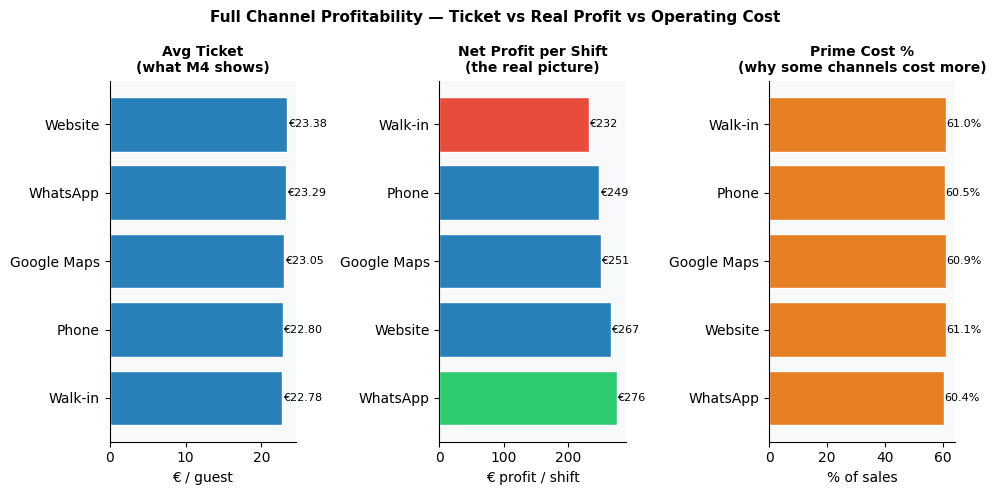


  Recommendations:
  - WhatsApp generates the highest real net profit.
     This is your most valuable channel — protect and grow it.
  - Website had the highest ticket but NOT the highest profit.
     Investigate why: higher prime cost? More no-shows? More discounts?
  - Walk-in has the lowest net margin.
     Before cutting it, check its sales weight — if it drives volume
     it may still be worth keeping at a reduced investment.
  - Focus marketing budget on net profit per channel,
     not on ticket or volume alone.


In [14]:
# CALCULATION 
channel_stats = df.groupby("booking_channel").agg(
    avg_ticket     = ("avg_ticket_eur", "mean"),
    avg_sales      = ("sales_eur",      "mean"),
    avg_net_profit = ("net_profit_eur", "mean"),
    avg_prime_cost = ("prime_cost_pct", "mean"),
    record_count   = ("sales_eur",      "count"),
).round(2)

channel_stats["net_margin_pct"] = (
    channel_stats["avg_net_profit"] / channel_stats["avg_sales"] * 100
).round(1)
channel_stats["sales_weight_pct"] = (
    channel_stats["avg_sales"] * channel_stats["record_count"] /
    (channel_stats["avg_sales"] * channel_stats["record_count"]).sum() * 100
).round(1)

# Key insight: rank by net profit, NOT by ticket
channel_stats = channel_stats.sort_values("avg_net_profit", ascending=False)

best_channel  = channel_stats["avg_net_profit"].idxmax()
worst_channel = channel_stats["avg_net_profit"].idxmin()

# Detect if the ranking changed vs ticket ranking (the "aha moment" for the client)
best_by_ticket = channel_stats["avg_ticket"].idxmax()
ranking_changed = best_by_ticket != best_channel

print("=" * 65)
print(" Full Profitability by Booking Channel")
print("=" * 65)

if ranking_changed:
    print(f"\n  KEY INSIGHT: The ranking changes when you look at net profit.")
    print(f"  Best channel by ticket     : {best_by_ticket}")
    print(f"  Best channel by net profit : {best_channel}")
    print(f"  High ticket ≠ high profit. Operating costs make the difference.")
else:
    print(f"\n  Consistent: {best_channel} leads on both ticket and net profit.")

print(f"\n  {'Channel':<18} {'Ticket':<10} {'Net Profit':<14} {'Margin%':<10} {'Prime Cost%':<14} {'Weight%'}")
print(f"  {'-'*72}")
for channel, row in channel_stats.iterrows():
    icon = "🏆" if channel == best_channel else "🔴" if channel == worst_channel else "  "
    print(f"  {icon} {channel:<16} €{row['avg_ticket']:>5.2f}   "
          f"€{row['avg_net_profit']:>7.2f}      "
          f"{row['net_margin_pct']:>5.1f}%      "
          f"{row['avg_prime_cost']:>5.1f}%          "
          f"{row['sales_weight_pct']:>4.1f}%")

# CHART 
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

bar_colors = [
    COLORS["green"] if v == channel_stats["avg_net_profit"].max()
    else COLORS["red"] if v == channel_stats["avg_net_profit"].min()
    else COLORS["blue"]
    for v in channel_stats["avg_net_profit"].values
]

# Left: average ticket — same as M4 for comparison
axes[0].barh(channel_stats.sort_values("avg_ticket").index,
             channel_stats.sort_values("avg_ticket")["avg_ticket"],
             color=COLORS["blue"], edgecolor="white")
axes[0].set_title("Avg Ticket\n(what M4 shows)", fontweight="bold", fontsize=10)
axes[0].set_xlabel("€ / guest")
for i, v in enumerate(channel_stats.sort_values("avg_ticket")["avg_ticket"].values):
    axes[0].text(v + 0.1, i, f"€{v:.2f}", va="center", fontsize=8)

# Middle: net profit — the real picture
axes[1].barh(channel_stats.index, channel_stats["avg_net_profit"],
             color=bar_colors, edgecolor="white")
axes[1].set_title("Net Profit per Shift\n(the real picture)", fontweight="bold", fontsize=10)
axes[1].set_xlabel("€ profit / shift")
for i, v in enumerate(channel_stats["avg_net_profit"].values):
    axes[1].text(v + 0.3, i, f"€{v:.0f}", va="center", fontsize=8)

# Right: prime cost — explains why some channels are less profitable
axes[2].barh(channel_stats.index, channel_stats["avg_prime_cost"],
             color=COLORS["orange"], edgecolor="white")
axes[2].set_title("Prime Cost %\n(why some channels cost more)", fontweight="bold", fontsize=10)
axes[2].set_xlabel("% of sales")
for i, v in enumerate(channel_stats["avg_prime_cost"].values):
    axes[2].text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8)

plt.suptitle("Full Channel Profitability — Ticket vs Real Profit vs Operating Cost",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/12_channel_full_profitability.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS 
print(f"\n  Recommendations:")
print(f"  - {best_channel} generates the highest real net profit.")
print(f"     This is your most valuable channel — protect and grow it.")
if ranking_changed:
    print(f"  - {best_by_ticket} had the highest ticket but NOT the highest profit.")
    print(f"     Investigate why: higher prime cost? More no-shows? More discounts?")
print(f"  - {worst_channel} has the lowest net margin.")
print(f"     Before cutting it, check its sales weight — if it drives volume")
print(f"     it may still be worth keeping at a reduced investment.")
print(f"  - Focus marketing budget on net profit per channel,")
print(f"     not on ticket or volume alone.")

### 13. Feature Importance — What Drives Sales?

 Feature Importance — What Drives Sales?

  Model: R²=0.663  MAE=±€342 per shift
  Explains 66.3% of the variation in sales



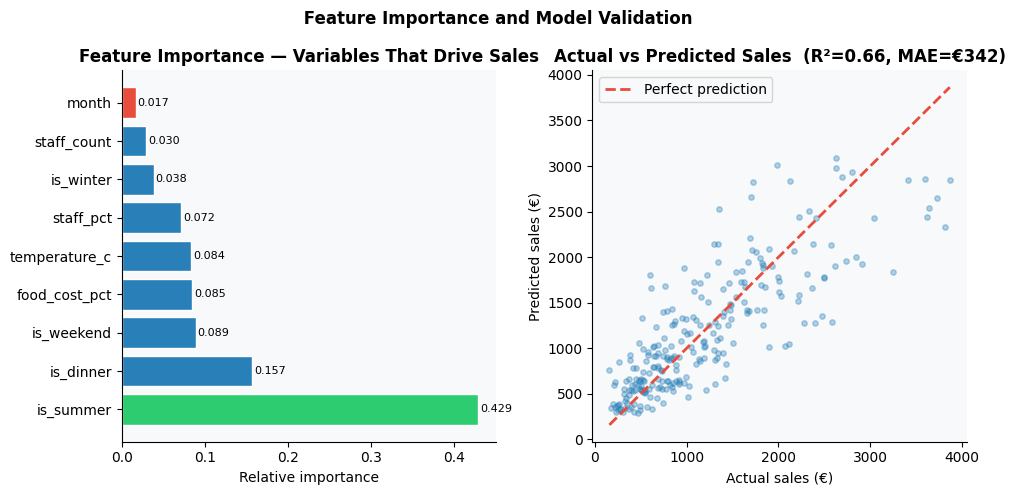


   Recommendations:
  - 'is_summer' is the strongest predictor of sales.
     Controlling or anticipating it has more impact than any other variable.
  - The model predicts sales with ±€342 error per shift.
     Use it to plan purchases and staffing 1–2 weeks in advance.
  - 'month' has the least predictive power.
     It adds little information to the model.


In [16]:
# FEATURE ENCODING 
# Random Forest only works with numeric values.
# We encode categorical variables as binary (0/1) columns.
df["is_dinner"]  = (df["shift"] == "Dinner").astype(int)  # Dinner=1, Lunch=0
df["is_weekend"] = df["day_of_week"].isin(["Friday","Saturday","Sunday"]).astype(int)
df["is_summer"]  = df["month"].isin([6,7,8,9]).astype(int)
df["is_winter"]  = df["month"].isin([12,1,2]).astype(int)

# Features the model receives BEFORE each shift — things the owner knows in advance
FEATURES = [
    "is_dinner",       # Dinner (1) or lunch (0)
    "is_weekend",      # Weekend shift or not
    "is_summer",       # Summer season (Jun–Sep)
    "is_winter",       # Winter season (Dec–Feb)
    "month",           # Month of the year (captures annual seasonality)
    "staff_count",     # Staff planned for the shift
    "temperature_c",   # Outdoor temperature (valid predictor after dataset fix)
    "food_cost_pct",   # Food cost control for that shift
    "staff_pct",       # Staff cost as % of sales
]

# MODEL TRAINING
X = df[FEATURES].values
y = df["sales_eur"].values

# 75% training, 25% test
# The model learns on 75% and is evaluated on unseen data (25%)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

mae = mean_absolute_error(y_te, y_pred)
r2  = r2_score(y_te, y_pred)

# feature_importances_: value between 0 and 1 per feature (sum = 1.0)
# Higher value = more useful that feature was for the model
importances = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=False)

print("=" * 55)
print(" Feature Importance — What Drives Sales?")
print("=" * 55)
print(f"\n  Model: R²={r2:.3f}  MAE=±€{mae:.0f} per shift")
print(f"  Explains {r2*100:.1f}% of the variation in sales\n")

# CHART
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: feature importance bar chart
# Green = most important, red = least important, blue = the rest
fi_colors = [
    COLORS["green"] if v == importances.max()
    else COLORS["red"] if v == importances.min()
    else COLORS["blue"]
    for v in importances.values
]
axes[0].barh(importances.index, importances.values,
             color=fi_colors, edgecolor="white")
axes[0].set_title("Feature Importance — Variables That Drive Sales",
                  fontweight="bold")
axes[0].set_xlabel("Relative importance")
for i, v in enumerate(importances.values):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)

# Right: actual vs predicted sales scatter plot
# Points close to the dashed line = accurate predictions
sample = min(250, len(y_te))
axes[1].scatter(y_te[:sample], y_pred[:sample],
                alpha=0.35, color=COLORS["blue"], s=15)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
axes[1].plot(lims, lims, color=COLORS["red"],
             linewidth=2, linestyle="--", label="Perfect prediction")
axes[1].set_title(f"Actual vs Predicted Sales  (R²={r2:.2f}, MAE=€{mae:.0f})",
                  fontweight="bold")
axes[1].set_xlabel("Actual sales (€)")
axes[1].set_ylabel("Predicted sales (€)")
axes[1].legend()

plt.suptitle(" Feature Importance and Model Validation",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/13_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS
top_feature    = importances.idxmax()
bottom_feature = importances.idxmin()
print(f"\n   Recommendations:")
print(f"  - '{top_feature}' is the strongest predictor of sales.")
print(f"     Controlling or anticipating it has more impact than any other variable.")
print(f"  - The model predicts sales with ±€{mae:.0f} error per shift.")
print(f"     Use it to plan purchases and staffing 1–2 weeks in advance.")
print(f"  - '{bottom_feature}' has the least predictive power.")
print(f"     It adds little information to the model.")

### 14. Optimal Shift x Day Combination

Optimal Shift x Day Combination

  Shift + Day              Net Profit     Sales          Decision
  -----------------------------------------------------------------
  Dinner Saturday          €  533.31     €1,831.33     Keep
  Dinner Friday            €  483.41     €1,693.05     Keep
  Dinner Sunday            €  444.22     €1,688.47     Keep
  Dinner Wednesday         €  349.77     €1,408.50     Keep
  Dinner Tuesday           €  335.15     €1,273.80     Keep
  Dinner Thursday          €  273.25     €1,144.66     Optimize
  Lunch Saturday           €  244.92     €1,104.54     Optimize
  Lunch Sunday             €  226.17     €1,095.37     Optimize
  Lunch Friday             €  184.36     €  982.26     Optimize
  Dinner Monday            €  150.25     €  843.56     Reconsider
  Lunch Thursday           €  132.48     €  805.60     Reconsider
  Lunch Wednesday          €  110.87     €  777.84     Reconsider
  Lunch Tuesday            €  105.25     €  780.61     Reconsider
  Lunch Monda

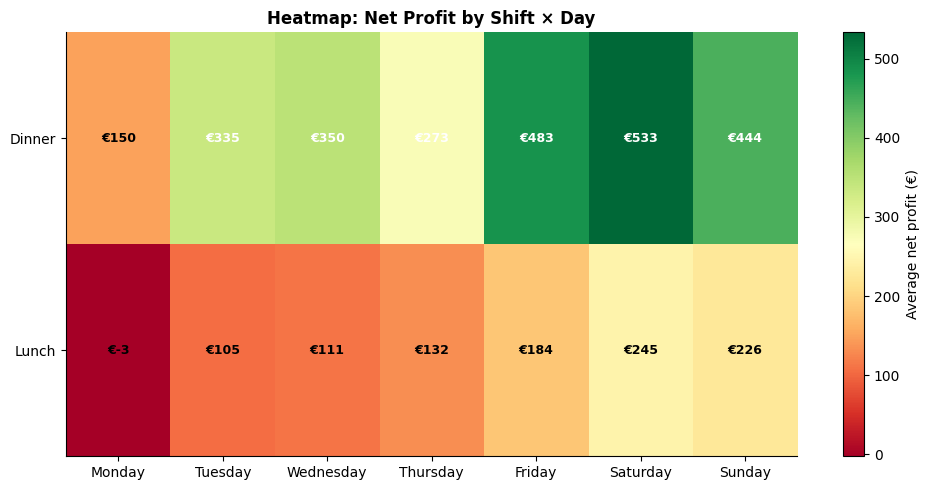


  Recommendations:
  - Protect 'Dinner Saturday': your most profitable slot
     at €533.31/shift.
  - 'Lunch Monday' generates a loss of
     €2.55/shift → €133/year.
     Consider closing it or converting it to a special event.
  - Use the heatmap in client meetings: it communicates instantly
     which slots are worth keeping and which to reconsider.


In [17]:
# Each combination represents one opening decision.
# Sorted by net profit to clearly show which slots to keep and which to reconsider.
DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

combinations = df.groupby(["shift","day_of_week"]).agg(
    avg_net_profit = ("net_profit_eur", "mean"),
    avg_sales      = ("sales_eur",      "mean"),
    avg_covers     = ("covers",         "mean"),
).round(2).reset_index()

combinations["label"] = combinations["shift"] + " " + combinations["day_of_week"]
combinations = combinations.sort_values("avg_net_profit", ascending=False)

# Top 33%    - Keep:      these slots are your most profitable
# Middle 33% - Optimize:  potential to improve with targeted actions
# Bottom 33% - Reconsider: evaluate closing, repricing or restructuring
thr_high = combinations["avg_net_profit"].quantile(0.67)
thr_low  = combinations["avg_net_profit"].quantile(0.33)

combinations["decision"] = combinations["avg_net_profit"].apply(
    lambda v:
    "Keep"      if v >= thr_high
    else ("Optimize"  if v >= thr_low
          else "Reconsider")
)

print("=" * 55)
print("Optimal Shift x Day Combination")
print("=" * 55)
print(f"\n  {'Shift + Day':<24} {'Net Profit':<14} {'Sales':<14} {'Decision'}")
print(f"  {'-'*65}")
for _, row in combinations.iterrows():
    print(f"  {row['label']:<24} €{row['avg_net_profit']:>8,.2f}     "
          f"€{row['avg_sales']:>8,.2f}     {row['decision']}")

# Slots to reconsider
reconsider = combinations[combinations["decision"] == "Reconsider"]
print(f"\n  Slots to reconsider: {len(reconsider)}")
for _, row in reconsider.iterrows():
    print(f"  {row['label']}: avg net profit €{row['avg_net_profit']:,.2f}/shift")

# The heatmap is the most powerful visual for this analysis.
# Red = unprofitable slots, green = best slots.
# The client sees the full picture at a glance.
pivot = combinations.pivot(
    index="shift", columns="day_of_week", values="avg_net_profit"
)
# Reorder columns Monday → Sunday
ordered_days = [d for d in DAY_ORDER if d in pivot.columns]
pivot = pivot[ordered_days]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    pivot.values, aspect="auto",
    cmap="RdYlGn",           # Red = low profit, Yellow = neutral, Green = high profit
    vmin=pivot.values.min(),
    vmax=pivot.values.max()
)

ax.set_xticks(range(len(ordered_days)))
ax.set_xticklabels(ordered_days, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

# Euro value label inside each cell
# White text on dark cells, black text on light cells
for i in range(len(pivot.index)):
    for j in range(len(ordered_days)):
        val = pivot.values[i, j]
        ax.text(j, i, f"€{val:.0f}",
                ha="center", va="center",
                fontsize=9, fontweight="bold",
                color="white" if abs(val) > abs(pivot.values).max() * 0.5
                else "black")

plt.colorbar(im, ax=ax, label="Average net profit (€)")
ax.set_title("Heatmap: Net Profit by Shift × Day",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/14_heatmap_shift_day.png", dpi=150, bbox_inches="tight")
plt.show()

# RECOMMENDATIONS 
best_slot  = combinations.iloc[0]
worst_slot = combinations.iloc[-1]

print(f"\n  Recommendations:")
print(f"  - Protect '{best_slot['label']}': your most profitable slot")
print(f"     at €{best_slot['avg_net_profit']:,.2f}/shift.")
if worst_slot["avg_net_profit"] < 0:
    print(f"  - '{worst_slot['label']}' generates a loss of")
    print(f"     €{abs(worst_slot['avg_net_profit']):,.2f}/shift → €{abs(worst_slot['avg_net_profit'])*52:,.0f}/year.")
    print(f"     Consider closing it or converting it to a special event.")
print(f"  - Use the heatmap in client meetings: it communicates instantly")
print(f"     which slots are worth keeping and which to reconsider.")

### 15.  ML Model — Next 4 Weeks Forecast

 ML Model — Next 4 Weeks Forecast

  Model A (covers) : R²=0.469  MAE=±12 guests/shift
  Model B (profit) : R²=0.554  MAE=±€154/shift

  Relative error — covers : 25.3% ( > 15%)
  Relative error — profit : 56.0% ( > 15%)

  Historical January avg temperature: 14.8°C

 Weekly forecast (next 4 weeks):

  Week     Covers       Profit         Avg Temp     Avg Staff
  ----------------------------------------------------------
  Week 1         391     €     216      13.3°C         4
  Week 2         464     €     270      15.3°C         3
  Week 3         452     €     226      16.8°C         5
  Week 4         483     €     536      15.8°C         4

  4-week totals:
  Expected covers : 1,790
  Expected profit : €1,249

  Model error margin:
  ±12 covers/shift  |  ±€154 profit/shift


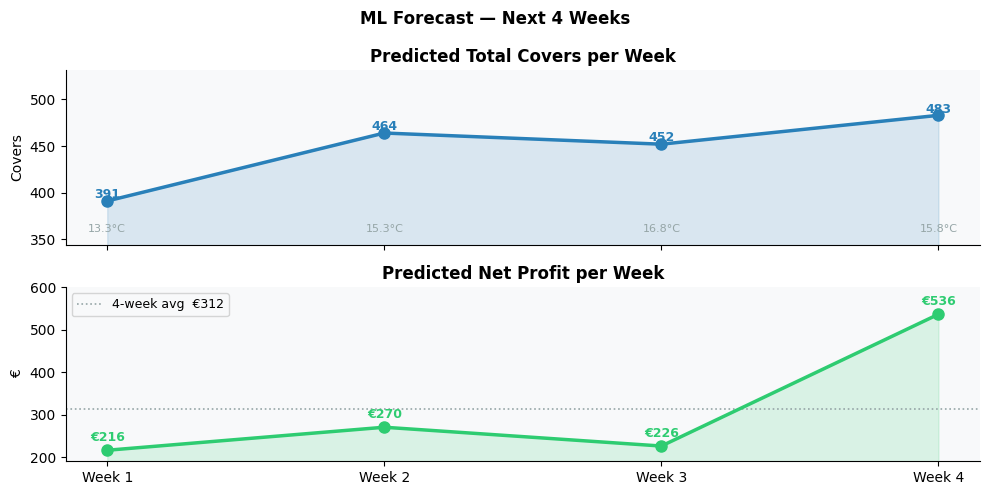


 Recommendations:
  - Week 4 is forecast as the most profitable (avg temp 15.8°C).
     Ensure full staffing and sufficient stock for that week.
  - Week 1 is the weakest (avg temp 13.3°C).
     Consider a midweek promotion to boost covers.
  - Run this model monthly with the actual weather forecast
     for that month to keep predictions accurate.


In [18]:
# CALCULATION 
if "is_dinner" not in df.columns:
    df["is_dinner"]  = (df["shift"] == "Dinner").astype(int)
    df["is_weekend"] = df["day_of_week"].isin(["Friday","Saturday","Sunday"]).astype(int)
    df["is_summer"]  = df["month"].isin([6,7,8,9]).astype(int)
    df["is_winter"]  = df["month"].isin([12,1,2]).astype(int)

PRED_FEATURES = [
    "is_dinner", "is_weekend", "is_summer", "is_winter",
    "month", "staff_count", "temperature_c"
]

# MODEL A: PREDICT COVERS
X_cov = df[PRED_FEATURES].values
y_cov = df["covers"].values
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_cov, y_cov, test_size=0.25, random_state=42)
rf_covers = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf_covers.fit(Xtr_c, ytr_c)
mae_cov = mean_absolute_error(yte_c, rf_covers.predict(Xte_c))
r2_cov  = r2_score(yte_c, rf_covers.predict(Xte_c))

# MODEL B: PREDICT NET PROFIT 
X_ben = df[PRED_FEATURES].values
y_ben = df["net_profit_eur"].values
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(X_ben, y_ben, test_size=0.25, random_state=42)
rf_profit = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf_profit.fit(Xtr_b, ytr_b)
mae_ben = mean_absolute_error(yte_b, rf_profit.predict(Xte_b))
r2_ben  = r2_score(yte_b, rf_profit.predict(Xte_b))

print("=" * 55)
print(" ML Model — Next 4 Weeks Forecast")
print("=" * 55)
print(f"\n  Model A (covers) : R²={r2_cov:.3f}  MAE=±{mae_cov:.0f} guests/shift")
print(f"  Model B (profit) : R²={r2_ben:.3f}  MAE=±€{mae_ben:.0f}/shift")

# Relative error check against the <15% target
err_pct_cov = mae_cov / df["covers"].mean() * 100
err_pct_ben = mae_ben / df["net_profit_eur"].abs().mean() * 100
print(f"\n  Relative error — covers : {err_pct_cov:.1f}% "
      f"({'< 15%' if err_pct_cov < 15 else ' > 15%'})")
print(f"  Relative error — profit : {err_pct_ben:.1f}% "
      f"({'< 15%' if err_pct_ben < 15 else ' > 15%'})")

# GENERATE NEXT 4 WEEKS — WITH WEEKLY VARIATION 
# Each week has slightly different inputs to produce meaningful variation:
#   - Temperature shifts week by week (January in Málaga can vary several degrees)
#   - Staff adjusts for local events, long weekends or quiet spells
jan_avg_temp = df[df["month"] == 1]["temperature_c"].mean()
print(f"\n  Historical January avg temperature: {jan_avg_temp:.1f}°C")

# Weekly adjustments relative to the January baseline
temp_adj  = {1: -1.5, 2: +0.5, 3: +2.0, 4: +1.0}
staff_adj = {1:  0,   2: -1,   3: +1,   4:  0}

future_dates   = pd.date_range("2025-01-01", periods=28, freq="D")
future_records = []

for date in future_dates:
    for shift in ["Lunch", "Dinner"]:
        month    = date.month
        day      = date.day_name()
        week_num = (date - future_dates[0]).days // 7 + 1

        temp       = round(jan_avg_temp + temp_adj[week_num], 1)
        staff_base = 5 if day in ["Friday","Saturday","Sunday"] else 4
        staff      = max(2, staff_base + staff_adj[week_num])

        future_records.append({
            "date":          date,
            "shift":         shift,
            "is_dinner":     1 if shift == "Dinner" else 0,
            "is_weekend":    1 if day in ["Friday","Saturday","Sunday"] else 0,
            "is_summer":     0,
            "is_winter":     1,
            "month":         month,
            "staff_count":   staff,
            "temperature_c": temp,
        })

df_future        = pd.DataFrame(future_records)
X_fut            = df_future[PRED_FEATURES].values
df_future["covers_pred"] = rf_covers.predict(X_fut).round(0).astype(int)
df_future["profit_pred"] = rf_profit.predict(X_fut).round(2)

# ── WEEKLY SUMMARY ────────────────────────────────────────────────────────────
df_future["day_offset"] = (df_future["date"] - df_future["date"].min()).dt.days
df_future["week"]       = (df_future["day_offset"] // 7) + 1

weekly_summary = df_future.groupby("week").agg(
    total_covers = ("covers_pred",  "sum"),
    total_profit = ("profit_pred",  "sum"),
    avg_temp     = ("temperature_c","mean"),
    avg_staff    = ("staff_count",  "mean"),
    shifts       = ("shift",        "count"),
).round(2)

print(f"\n Weekly forecast (next 4 weeks):\n")
print(f"  {'Week':<8} {'Covers':<12} {'Profit':<14} {'Avg Temp':<12} {'Avg Staff'}")
print(f"  {'-'*58}")
for week, row in weekly_summary.iterrows():
    # ← .0f used throughout instead of d to avoid float/int type errors in iterrows()
    print(f"  Week {week:<3.0f}  {row['total_covers']:>8,.0f}     "
          f"€{row['total_profit']:>8,.0f}     "
          f"{row['avg_temp']:>5.1f}°C       "
          f"{row['avg_staff']:>3.0f}")

print(f"\n  4-week totals:")
print(f"  Expected covers : {weekly_summary['total_covers'].sum():,.0f}")
print(f"  Expected profit : €{weekly_summary['total_profit'].sum():,.0f}")
print(f"\n  Model error margin:")
print(f"  ±{mae_cov:.0f} covers/shift  |  ±€{mae_ben:.0f} profit/shift")

# CHART 
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

week_labels = [f"Week {w}" for w in weekly_summary.index]
x           = np.arange(len(week_labels))

# Top: predicted covers per week 
axes[0].plot(x, weekly_summary["total_covers"],
             color=COLORS["blue"], linewidth=2.5,
             marker="o", markersize=8, zorder=3)
axes[0].fill_between(x, weekly_summary["total_covers"],
                     alpha=0.15, color=COLORS["blue"])

for i, v in enumerate(weekly_summary["total_covers"]):
    axes[0].text(i, v + 3, f"{v:,.0f}",
                 ha="center", fontsize=9, fontweight="bold",
                 color=COLORS["blue"])

# Temperature annotation below each point
for i, (week, row) in enumerate(weekly_summary.iterrows()):
    axes[0].text(i, weekly_summary["total_covers"].min() * 0.915,
                 f"{row['avg_temp']:.1f}°C",
                 ha="center", fontsize=8, color=COLORS["gray"])

axes[0].set_title("Predicted Total Covers per Week", fontweight="bold")
axes[0].set_ylabel("Covers")
axes[0].set_xticks(x)
axes[0].set_xticklabels(week_labels)
axes[0].set_ylim(weekly_summary["total_covers"].min() * 0.88,
                 weekly_summary["total_covers"].max() * 1.10)

# ── Bottom: predicted net profit per week ─────────────────────────────────────
profit_vals = weekly_summary["total_profit"].values
line_color  = COLORS["green"] if all(v >= 0 for v in profit_vals) else COLORS["orange"]

axes[1].plot(x, profit_vals,
             color=line_color, linewidth=2.5,
             marker="o", markersize=8, zorder=3)
axes[1].fill_between(x, profit_vals,
                     alpha=0.15, color=line_color)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# 4-week average reference line
avg_profit = weekly_summary["total_profit"].mean()
axes[1].axhline(avg_profit, color=COLORS["gray"],
                linewidth=1.2, linestyle=":",
                label=f"4-week avg  €{avg_profit:,.0f}")

for i, v in enumerate(profit_vals):
    offset = 15  if v >= 0 else -30
    va     = "bottom" if v >= 0 else "top"
    axes[1].text(i, v + offset, f"€{v:,.0f}",
                 ha="center", fontsize=9, fontweight="bold",
                 color=line_color, va=va)

axes[1].set_title("Predicted Net Profit per Week", fontweight="bold")
axes[1].set_ylabel("€")
axes[1].set_xticks(x)
axes[1].set_xticklabels(week_labels)
axes[1].set_ylim(
    min(profit_vals) * 1.20 if min(profit_vals) < 0 else min(profit_vals) * 0.88,
    max(profit_vals) * 1.12
)
axes[1].legend(fontsize=9)

plt.suptitle("ML Forecast — Next 4 Weeks",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/15_forecast_4_weeks.png", dpi=150, bbox_inches="tight")
plt.show()

# ── RECOMMENDATIONS ───────────────────────────────────────────────────────────
best_week  = weekly_summary["total_profit"].idxmax()
worst_week = weekly_summary["total_profit"].idxmin()

print(f"\n Recommendations:")
print(f"  - Week {best_week:.0f} is forecast as the most profitable "
      f"(avg temp {weekly_summary.loc[best_week, 'avg_temp']:.1f}°C).")
print(f"     Ensure full staffing and sufficient stock for that week.")
print(f"  - Week {worst_week:.0f} is the weakest "
      f"(avg temp {weekly_summary.loc[worst_week, 'avg_temp']:.1f}°C).")
print(f"     Consider a midweek promotion to boost covers.")
print(f"  - Run this model monthly with the actual weather forecast")
print(f"     for that month to keep predictions accurate.")

## Dashboard

In [59]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# DEPENDENCY CHECK 
errors = []
if "importances"    not in dir(): errors.append("Run Question 13 first")
if "weekly_summary" not in dir(): errors.append("Run Question 15 first")
if "df"             not in dir(): errors.append("Run dataset creation first")
if errors:
    for e in errors: print(e)
    raise SystemExit("Fix the errors above before running the dashboard.")
else:
    print("All dependencies ready - building dashboard...")

# DASHBOARD SETUP 
fig = make_subplots(
    rows=4, cols=3,
    subplot_titles=(
        " Sales by Day of the Week",
        " Avg Ticket - Lunch vs Dinner",
        " Food Cost % by Month",
        " RevPASH by Day",
        " Net Profit Heatmap - Shift × Day",
        " Forecast - Covers (next 4 weeks)",
        " Forecast - Net Profit (next 4 weeks)",
        " Feature Importance",
    ),
    specs=[
        [{"type": "bar"},     {"type": "bar"},                   {"type": "bar"}],
        [{"type": "bar"},     {"type": "heatmap", "colspan": 2}, None            ],
        [{"type": "scatter"}, {"type": "scatter"},               {"type": "bar"} ],
        [None,                None,                              None            ],
    ],
    vertical_spacing=0.10,
    horizontal_spacing=0.08,
)

# COLOR SHORTCUTS 
C_BLUE   = COLORS["blue"]
C_GREEN  = COLORS["green"]
C_RED    = COLORS["red"]
C_ORANGE = COLORS["orange"]
C_PURPLE = COLORS["purple"]
C_GRAY   = COLORS["gray"]

# CONSTANTS 
DAY_ORDER    = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
MONTH_LABELS = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
BENCHMARK_MAX     = 35.0
REVPASH_THRESHOLD = 8.0


# CHART 1 — Sales by Day of the Week (row=1, col=1)

sales_by_day = df.groupby("day_of_week")["sales_eur"].mean().reindex(DAY_ORDER)

fig.add_trace(
    go.Bar(
        x=DAY_ORDER,
        y=sales_by_day.values,
        marker_color=[
            C_GREEN if v == sales_by_day.max()
            else C_RED if v == sales_by_day.min()
            else C_BLUE
            for v in sales_by_day.values
        ],
        text=[f"€{v:,.0f}" for v in sales_by_day.values],
        textposition="outside",
        hovertemplate="<b>%{x}</b><br>Avg Sales: €%{y:,.0f}<extra></extra>",
        showlegend=False,
    ),
    row=1, col=1
)


# CHART 2 — Avg Ticket Lunch vs Dinner (row=1, col=2)

ticket_by_shift = df.groupby("shift")["avg_ticket_eur"].mean()

fig.add_trace(
    go.Bar(
        x=ticket_by_shift.index.tolist(),
        y=ticket_by_shift.values,
        marker_color=[C_BLUE, C_ORANGE],
        text=[f"€{v:.2f}" for v in ticket_by_shift.values],
        textposition="outside",
        hovertemplate="<b>%{x}</b><br>Avg Ticket: €%{y:.2f}/guest<extra></extra>",
        showlegend=False,
    ),
    row=1, col=2
)


# CHART 3 — Food Cost % by Month (row=1, col=3)

fc_by_month = df.groupby("month")["food_cost_pct"].mean()

fig.add_trace(
    go.Bar(
        x=[MONTH_LABELS[m] for m in fc_by_month.index],
        y=fc_by_month.values,
        marker_color=[
            C_RED if v > BENCHMARK_MAX else C_GREEN
            for v in fc_by_month.values
        ],
        hovertemplate="<b>%{x}</b><br>Food Cost: %{y:.1f}%<br>Limit: 35%<extra></extra>",
        showlegend=False,
    ),
    row=1, col=3
)
fig.add_hline(
    y=BENCHMARK_MAX, line_dash="dash", line_color=C_RED,
    annotation_text="Limit 35%", annotation_position="top right",
    row=1, col=3
)


# CHART 4 - RevPASH by Day (row=2, col=1)

revpash_day = df.groupby("day_of_week")["revpash_eur"].mean().reindex(DAY_ORDER)

fig.add_trace(
    go.Bar(
        x=DAY_ORDER,
        y=revpash_day.values,
        marker_color=[
            C_GREEN if v >= REVPASH_THRESHOLD else C_RED
            for v in revpash_day.values
        ],
        hovertemplate="<b>%{x}</b><br>RevPASH: €%{y:.2f}/seat/h<br>Threshold: €8<extra></extra>",
        showlegend=False,
    ),
    row=2, col=1
)
fig.add_hline(
    y=REVPASH_THRESHOLD, line_dash="dash", line_color=C_RED,
    annotation_text="Threshold €8", annotation_position="top right",
    row=2, col=1
)


# CHART 5 - Heatmap Net Profit Shift × Day (row=2, col=2)

combinations = df.groupby(["shift","day_of_week"])["net_profit_eur"].mean().round(2)
pivot        = combinations.unstack(level="day_of_week")
ordered_days = [d for d in DAY_ORDER if d in pivot.columns]
pivot        = pivot[ordered_days]

fig.add_trace(
    go.Heatmap(
        z=pivot.values,
        x=ordered_days,
        y=pivot.index.tolist(),
        colorscale="RdYlGn",
        text=[[f"€{v:.0f}" for v in row] for row in pivot.values],
        texttemplate="%{text}",
        hovertemplate="<b>%{y} — %{x}</b><br>Avg Net Profit: €%{z:.0f}<extra></extra>",
        showscale=True,
        colorbar=dict(title="€", len=0.25, y=0.65),
    ),
    row=2, col=2
)


# CHART 6 - 4-Week Forecast Covers (row=3, col=1)
# weekly_summary from Question 15

week_labels = [f"Week {w}" for w in weekly_summary.index]
profit_vals = weekly_summary["total_profit"].values
line_color  = C_GREEN if all(v >= 0 for v in profit_vals) else C_ORANGE
fill_color  = "rgba(46,204,113,0.12)" if all(v >= 0 for v in profit_vals) \
              else "rgba(230,126,34,0.12)"

fig.add_trace(
    go.Scatter(
        x=week_labels,
        y=weekly_summary["total_covers"].values,
        mode="lines+markers+text",
        line=dict(color=C_BLUE, width=2.5),
        marker=dict(size=8),
        text=[f"{v:,.0f}" for v in weekly_summary["total_covers"].values],
        textposition="top center",
        textfont=dict(size=9, color=C_BLUE),
        fill="tozeroy",
        fillcolor="rgba(41,128,185,0.12)",
        hovertemplate="<b>%{x}</b><br>Covers: %{y:,.0f}<extra></extra>",
        showlegend=False,
    ),
    row=3, col=1
)

fig.update_yaxes(range=[0, weekly_summary["total_covers"].max() * 1.20], row=3, col=1)
fig.update_xaxes(range=[-0.3, len(week_labels) - 0.7], row=3, col=1)


# CHART 7 - 4-Week Forecast Net Profit (row=3, col=2)

avg_profit = weekly_summary["total_profit"].mean()

fig.add_trace(
    go.Scatter(
        x=week_labels,
        y=profit_vals,
        mode="lines+markers+text",
        line=dict(color=line_color, width=2.5),
        marker=dict(size=8),
        text=[f"€{v:,.0f}" for v in profit_vals],
        textposition="top center",
        textfont=dict(size=9, color=line_color),
        fill="tozeroy",
        fillcolor=fill_color,
        hovertemplate="<b>%{x}</b><br>Net Profit: €%{y:,.0f}<extra></extra>",
        showlegend=False,
    ),
    row=3, col=2
)
# 
fig.update_yaxes(range=[min(0, profit_vals.min() * 1.10), profit_vals.max() * 1.20], row=3, col=2)
fig.update_xaxes(range=[-0.3, len(week_labels) - 0.7], row=3, col=2)

fig.add_hline(
    y=avg_profit, line_dash="dot", line_color=C_GRAY,
    annotation_text=f"Avg €{avg_profit:,.0f}",
    annotation_position="top right",
    row=3, col=2
)


# CHART 8 - Feature Importance (row=3, col=3)
# Uses importances from Question 13

importances_sorted = importances.sort_values(ascending=True)

fig.add_trace(
    go.Bar(
        x=importances_sorted.values,
        y=importances_sorted.index.tolist(),
        orientation="h",
        marker_color=[
            C_GREEN if v == importances_sorted.max()
            else C_RED if v == importances_sorted.min()
            else C_BLUE
            for v in importances_sorted.values
        ],
        text=[f"{v:.3f}" for v in importances_sorted.values],
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Importance: %{x:.3f}<extra></extra>",
        showlegend=False,
    ),
    row=3, col=3
)


# GLOBAL LAYOUT

fig.update_layout(
    title=dict(
        text="Restaurant Analytics Dashboard - El Rincón, Málaga",
        font=dict(size=20, color="#2C3E50"),
        x=0.5,
        xanchor="center",
    ),
    height=1300,
    margin=dict(t=80, b=120, l=50, r=50),
    paper_bgcolor="white",
    plot_bgcolor="#F8F9FA",
    font=dict(family="DejaVu Sans", size=10, color="#2C3E50"),
    hoverlabel=dict(
        bgcolor="white",
        font_size=11,
        font_family="DejaVu Sans",
    ),
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor="#ECECEC")

# SAVE AND DISPLAY 
fig.write_html("outputs/dashboard_interactive.html")
print("Dashboard saved: outputs/dashboard_interactive.html")

pio.renderers.default = "browser"
fig.show()

All dependencies ready - building dashboard...
Dashboard saved: outputs/dashboard_interactive.html
